# Order Quantities When Demand is Approximately Level
### Interactive lecture notebook: EOQ, EPQ and Quantity Discounts
**Dr. Islam Ali** | Inventory and Production Management

---

This notebook follows the lecture slide by slide. For each concept it gives:

| Symbol | What you get |
|:-:|---|
| 📘 | **Theory**: definitions, assumptions and derivations (symbolic derivations are done with `sympy`) |
| 📊 | **Visualisations** that rebuild and extend the lecture figures |
| 🎛️ | **Interactive demonstrations** (sliders and buttons) for teaching in class and for self-study |
| 🧮 | **Worked examples** that read input data files from `data/` |
| 📄 | **PDF export**: every solution can be exported as a report with charts in `reports/` |
| ✍️ | **Practice problems** with an automatic answer checker |
| 🏭 | **Industrial tool** (Section 14): a documented lot-sizing tool for internships and jobs |

### Contents
0. [Setup, core functions and the PDF report engine](#s0)
1. [Inventory decisions](#s1)
2. [Deterministic single-item models](#s2)
3. [EOQ model assumptions](#s3)
4. [Notation and the inventory sawtooth](#s4)
5. [Cost components and the total relevant cost TRC(Q)](#s5)
6. [Derivation of the EOQ (Wilson formula) and TRC(EOQ)](#s6)
7. [Other expressions: months of supply and turnover ratio](#s7)
8. [Worked example 1: complete EOQ solution and PDF report](#s8)
9. [Sensitivity analysis: the percentage cost penalty (PCP)](#s9)
10. [Economic Production Quantity (EPQ)](#s10)
11. [Quantity discounts (all-units)](#s11)
12. [Practice problems with an automatic checker](#s12)
13. [Solve your own problem and export a full lecture report](#s13)
14. [🏭 Industrial tool: Lot-Sizing Decision Tool](#s14)
15. [Formula sheet](#s15)

### How to use this notebook
* **Instructor:** run all cells (*Kernel → Restart & Run All*), then move through the sections and use the 🎛️ widgets live.
* **Students:** change the numbers in the data files or in the widgets, predict the result first, then check it.
* Interactive widgets need `ipywidgets`. It works in Jupyter Lab, Jupyter Notebook, VS Code and Google Colab. If widgets are not available, every demo also has a plain function you can call with your own numbers.

**Folder layout the notebook expects**
```
EOQ_Lecture_Package/
├── 02_Order_Quantities_Level_Demand.ipynb   ← this notebook
├── data/              ← input data for the examples and practice problems
├── reports/           ← PDF reports exported by the notebook
└── industrial_tool/   ← the lot-sizing tool, its input/output files and user guide
```

<a id="s0"></a>
## 0. Setup, core functions and the PDF report engine
Run the next cells once. They import the libraries, set a consistent colour-blind-safe chart style, define the model functions used in the rest of the notebook, and create the `PDFReport` class that writes PDF reports.

In [3]:
# If a package is missing, uncomment the next line (in Colab most are already installed)
%pip install numpy pandas matplotlib sympy ipywidgets openpyxl

import os, sys, math, textwrap, datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.ticker import FuncFormatter, PercentFormatter
import sympy as sp
from IPython.display import display, Markdown, HTML

%matplotlib inline

try:
    import ipywidgets as w
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print("ipywidgets not found: interactive demos are disabled; call the demo functions directly instead.")

# ---- folders ----------------------------------------------------------------
BASE = os.path.abspath(".")
DATA_DIR = os.path.join(BASE, "data")
REPORT_DIR = os.path.join(BASE, "reports")
TOOL_DIR = os.path.join(BASE, "industrial_tool")
os.makedirs(REPORT_DIR, exist_ok=True)

# ---- colour-blind-safe palette: each colour has ONE meaning throughout ----------
C_ORDER  = "#2a78d6"   # blue    : ordering / replenishment cost, EOQ policy
C_CARRY  = "#eb6834"   # orange  : carrying cost, "current / alternative" policy
C_TOTAL  = "#4a3aa7"   # violet  : total relevant cost
C_DISC   = "#1baf7a"   # aqua    : discounted price curve
C_OPT    = "#008300"   # green   : optimum
C_BAD    = "#e34948"   # red     : penalty / non-optimal choice
C_YEL    = "#eda100"   # yellow  : highlights
C_INK, C_INK2, C_MUTED, C_GRID = "#0b0b0b", "#52514e", "#8a8984", "#e4e3df"
C_HEAD   = "#0f4c81"

plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 100, "savefig.dpi": 150,
    "axes.edgecolor": C_MUTED, "axes.labelcolor": C_INK2, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.titlelocation": "left", "axes.labelsize": 10,
    "xtick.color": C_INK2, "ytick.color": C_INK2, "axes.grid": True,
    "grid.color": C_GRID, "grid.linewidth": 0.8, "axes.spines.top": False,
    "axes.spines.right": False, "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.2, "font.size": 10,
})
money = FuncFormatter(lambda x, _: f"${x:,.0f}")
money2 = FuncFormatter(lambda x, _: f"${x:,.2f}")
print("Setup complete. Reports will be written to:", REPORT_DIR)


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------------------------------------

### 0.1 Core model library
Every formula in the lecture is written once as a small function, so the notebook and the students' own code use the same implementation.

In [4]:
# =============================== EOQ ==========================================
def eoq(A, D, v, r):
    """Wilson formula: EOQ = sqrt(2AD / vr)."""
    return np.sqrt(2 * A * D / (v * r))

def cost_replenishment(Q, A, D, v, include_vD=True):
    """C_r = (A + Qv) / (Q/D) = AD/Q + vD   ($/year)."""
    return A * D / Q + (v * D if include_vD else 0.0)

def cost_carrying(Q, v, r):
    """C_c = I_bar * v * r with I_bar = Q/2   ($/year)."""
    return Q / 2 * v * r

def trc(Q, A, D, v, r):
    """TRC(Q) = Qvr/2 + AD/Q   (vD omitted because it does not depend on Q)."""
    return Q * v * r / 2 + A * D / Q

def solve_eoq(A, D, v, r, Q_used=None):
    """Full EOQ solution as a dictionary (all lecture expressions)."""
    Q = eoq(A, D, v, r)
    out = {
        "EOQ (units)": Q,
        "TRC(EOQ) ($/yr)": np.sqrt(2 * A * D * v * r),
        "Ordering cost AD/Q ($/yr)": A * D / Q,
        "Carrying cost Qvr/2 ($/yr)": Q * v * r / 2,
        "Purchase cost vD ($/yr)": v * D,
        "Orders per year D/Q": D / Q,
        "Time between orders Q/D (years)": Q / D,
        "T_EOQ (months of supply)": np.sqrt(288 * A / (D * v * r)),
        "Time between orders (weeks)": 52 * Q / D,
        "Average inventory Q/2 (units)": Q / 2,
        "Average inventory value ($)": Q / 2 * v,
        "Turnover ratio TR = D/I_bar": np.sqrt(2 * v * r * D / A),
    }
    if Q_used is not None:
        alpha = Q_used / Q - 1
        out.update({"Q used (units)": Q_used, "alpha = Q'/EOQ - 1": alpha,
                    "TRC(Q used) ($/yr)": trc(Q_used, A, D, v, r),
                    "PCP of Q used (%)": pcp(alpha)})
    return out

# =============================== PCP ==========================================
def pcp(alpha):
    """Percentage cost penalty of ordering Q' = (1+alpha) EOQ:  50 alpha^2 / (1+alpha)."""
    alpha = np.asarray(alpha, dtype=float)
    return 50 * alpha ** 2 / (1 + alpha)

# =============================== EPQ ==========================================
def epq(A, D, v, r, m):
    """EPQ = sqrt(2AD / (vr(1 - D/m))) = EOQ / sqrt(1 - D/m)."""
    if m <= D:
        raise ValueError("Production rate m must exceed demand rate D.")
    return np.sqrt(2 * A * D / (v * r * (1 - D / m)))

def trc_epq(Q, A, D, v, r, m):
    """TRC(Q) = AD/Q + Q(1 - D/m)vr/2."""
    return A * D / Q + Q * (1 - D / m) * v * r / 2

def solve_epq(A, D, v, r, m, weeks_per_year=52):
    Q = epq(A, D, v, r, m)
    Imax = Q * (1 - D / m)
    return {
        "EPQ (units)": Q, "EOQ for comparison (units)": eoq(A, D, v, r),
        "EPQ / EOQ = 1/sqrt(1-D/m)": 1 / np.sqrt(1 - D / m),
        "TRC(EPQ) ($/yr)": trc_epq(Q, A, D, v, r, m),
        "Setup cost AD/Q ($/yr)": A * D / Q, "Carrying cost ($/yr)": Q * (1 - D / m) * v * r / 2,
        "Maximum inventory Q(1-D/m) (units)": Imax, "Average inventory (units)": Imax / 2,
        "Production runs per year D/Q": D / Q, "Cycle length Q/D (weeks)": weeks_per_year * Q / D,
        "Production run length Q/m (weeks)": weeks_per_year * Q / m,
        "Line idle time per cycle (weeks)": weeks_per_year * (Q / D - Q / m),
        "Utilisation of the line D/m": D / m,
    }

# ======================= ALL-UNITS QUANTITY DISCOUNT =========================
def unit_price(Q, v0, d, Q1):
    """All-units price: v0 for Q < Q1, v0(1-d) for Q >= Q1."""
    return np.where(np.asarray(Q) >= Q1, v0 * (1 - d), v0)

def trc_discount(Q, A, D, r, v0, d, Q1):
    """TRC(Q) including the acquisition cost Dv (piecewise, slide 21)."""
    v = unit_price(Q, v0, d, Q1)
    return A * D / Q + Q / 2 * v * r + D * v

def solve_all_units(A, D, r, v0, d, Q1, verbose=True):
    """Three-step procedure of slides 28-29.  Returns a dict and (optionally) prints the trace."""
    steps = []
    vd = v0 * (1 - d)
    eoq_d = eoq(A, D, vd, r)
    steps.append(f"Step 1: EOQ at the discounted price v0(1-d) = {vd:,.4f}:  EOQ(d) = sqrt(2AD/(v0(1-d)r)) = {eoq_d:,.2f}")
    eoq_0 = eoq(A, D, v0, r)
    trc_eoq0 = np.sqrt(2 * A * D * v0 * r) + D * v0
    trc_q1 = A * D / Q1 + Q1 / 2 * vd * r + D * vd
    if eoq_d >= Q1:
        steps.append(f"Step 2: EOQ(d) = {eoq_d:,.2f} >= Q1 = {Q1:,.0f}  ->  EOQ(d) is feasible and optimal (CASE 3). Stop.")
        case, Q_opt = 3, eoq_d
        cost = trc_discount(eoq_d, A, D, r, v0, d, Q1)
    else:
        steps.append(f"Step 2: EOQ(d) = {eoq_d:,.2f} < Q1 = {Q1:,.0f}  ->  go to step 3.")
        steps.append(f"Step 3: EOQ without discount = sqrt(2AD/(v0 r)) = {eoq_0:,.2f}")
        if eoq_0 >= Q1:
            # edge case not drawn in the slides: the no-discount curve keeps falling up to Q1
            steps.append(f"        Note: EOQ(no discount) >= Q1, so the no-discount segment is cheapest at Q1 itself, "
                         f"where the discount already applies  ->  order Q1 (CASE 1).")
            case, Q_opt, cost = 1, Q1, trc_q1
        else:
            steps.append(f"        TRC(EOQ) = sqrt(2AD v0 r) + D v0 = {trc_eoq0:,.2f}")
            steps.append(f"        TRC(Q1)  = AD/Q1 + Q1 v0(1-d) r/2 + D v0(1-d) = {trc_q1:,.2f}")
            if trc_eoq0 < trc_q1:
                steps.append("        TRC(EOQ) < TRC(Q1)  ->  ignore the discount, order EOQ (CASE 2).")
                case, Q_opt, cost = 2, eoq_0, trc_eoq0
            else:
                steps.append("        TRC(EOQ) > TRC(Q1)  ->  take the discount, order exactly Q1 (CASE 1).")
                case, Q_opt, cost = 1, Q1, trc_q1
    res = dict(case=case, Q_opt=Q_opt, TRC_opt=cost, EOQ_d=eoq_d, EOQ_0=eoq_0,
               TRC_EOQ0=trc_eoq0, TRC_Q1=trc_q1, price_paid=float(unit_price(Q_opt, v0, d, Q1)),
               annual_saving_vs_no_discount=trc_eoq0 - cost, steps=steps)
    if verbose:
        print("\n".join(steps))
        print(f"\n==> Optimal order quantity Q* = {Q_opt:,.2f}  (Case {case}),  total annual cost = ${cost:,.2f}")
    return res

# ============================== inventory profile =============================
def inventory_profile(Q, D, horizon, m=None, n=3000, start_full=True):
    """Inventory level over time for EOQ (m=None) or EPQ (finite rate m). Time unit = years."""
    t = np.linspace(0, horizon, n)
    T = Q / D
    tau = np.mod(t, T)
    if m is None:
        I = Q - D * tau
    else:
        tp = Q / m
        I = np.where(tau < tp, (m - D) * tau, Q * (1 - D / m) - D * (tau - tp))
    return t, I

print("Core library loaded:", ", ".join(["eoq", "trc", "solve_eoq", "pcp", "epq", "trc_epq", "solve_epq",
                                         "trc_discount", "solve_all_units", "inventory_profile"]))

Core library loaded: eoq, trc, solve_eoq, pcp, epq, trc_epq, solve_epq, trc_discount, solve_all_units, inventory_profile


### 0.2 PDF report engine
`PDFReport` writes multi-page A4 reports with a cover, text pages (math written as `$...$` is rendered), tables and figures. All the *export* functions in this notebook use it, so you can reuse it for your own assignments.

In [5]:
class PDFReport:
    """Minimal PDF report writer built on matplotlib (no extra dependencies).

    rep = PDFReport("reports/x.pdf", "Title", "Subtitle")
    rep.text("Heading", ["paragraph", "$EOQ=\\sqrt{2AD/vr}$", ...])
    rep.table(df_or_dict, "Table title")
    rep.figure(fig, "caption")
    rep.close()
    """
    FOOT = "Order Quantities When Demand is Approximately Level  |  Dr. Islam Ali"

    def __init__(self, path, title, subtitle="", author="Inventory and Production Management"):
        self.path, self.title, self.page = path, title, 0
        self.pdf = PdfPages(path)
        fig = plt.figure(figsize=(8.27, 11.69))
        fig.patches.append(plt.Rectangle((0, 0.70), 1, 0.30, transform=fig.transFigure, color=C_HEAD))
        fig.text(0.08, 0.88, "\n".join(textwrap.wrap(title, 34)), fontsize=24, color="white", weight="bold", va="top")
        fig.text(0.08, 0.745, subtitle, fontsize=12, color="#dce8f5")
        fig.text(0.08, 0.64, author, fontsize=11, color=C_INK2)
        fig.text(0.08, 0.615, f"Generated {dt.datetime.now():%d %B %Y, %H:%M}", fontsize=10, color=C_MUTED)
        self._save(fig, footer=False)

    def _save(self, fig, footer=True):
        self.page += 1
        if footer:
            fig.text(0.5, 0.015, f"{self.FOOT}   |   page {self.page}", ha="center", fontsize=7, color=C_MUTED)
        self.pdf.savefig(fig)
        plt.close(fig)

    def text(self, heading, lines, fontsize=10):
        """lines: list of strings. '## xxx' = sub-heading, '$...$' = math line (not wrapped)."""
        fig = plt.figure(figsize=(8.27, 11.69))
        fig.text(0.08, 0.95, heading, fontsize=16, weight="bold", color=C_HEAD)
        y = 0.91
        for ln in lines:
            if y < 0.06:
                self._save(fig)
                fig = plt.figure(figsize=(8.27, 11.69))
                fig.text(0.08, 0.95, heading + " (cont.)", fontsize=16, weight="bold", color=C_HEAD)
                y = 0.91
            if ln.startswith("## "):
                y -= 0.008
                fig.text(0.08, y, ln[3:], fontsize=fontsize + 2, weight="bold", color=C_INK)
                y -= 0.028
            elif ln.strip().startswith("$") and ln.strip().endswith("$"):
                fig.text(0.12, y, ln, fontsize=fontsize + 3, color=C_INK)
                y -= 0.042
            else:
                for sub in (textwrap.wrap(ln, 98) or [""]):
                    fig.text(0.08, y, sub, fontsize=fontsize, color=C_INK2)
                    y -= 0.021
                y -= 0.006
        self._save(fig)

    def table(self, data, title, fmt="{:,.4g}", col_width=None, landscape=False):
        if isinstance(data, dict):
            df = pd.DataFrame({"Quantity": list(data.keys()), "Value": list(data.values())})
        else:
            df = data.copy()
        cells = [[(fmt.format(x) if isinstance(x, (int, float, np.floating, np.integer)) and not isinstance(x, bool)
                   else str(x)) for x in row] for row in df.values]
        size = (11.69, 8.27) if landscape else (8.27, 11.69)
        fig, ax = plt.subplots(figsize=size)
        ax.axis("off")
        ax.set_title(title, fontsize=15, color=C_HEAD, pad=14, loc="left")
        tb = ax.table(cellText=cells, colLabels=list(df.columns), loc="upper center", cellLoc="center",
                      colWidths=col_width)
        tb.auto_set_font_size(False)
        tb.set_fontsize(9)
        tb.scale(1, 1.6)
        for (r_, c_), cell in tb.get_celld().items():
            cell.set_edgecolor(C_GRID)
            if r_ == 0:
                cell.set_facecolor(C_HEAD); cell.set_text_props(color="white", weight="bold")
            elif r_ % 2 == 0:
                cell.set_facecolor("#f4f6f9")
        self._save(fig)

    def figure(self, fig, caption=None):
        if caption:
            fig.text(0.01, 0.005, caption, fontsize=8, color=C_INK2, style="italic")
        self._save(fig)

    def close(self):
        d = self.pdf.infodict()
        d["Title"], d["Author"] = self.title, "Dr. Islam Ali - lecture notebook"
        self.pdf.close()
        print(f"PDF report saved: {self.path}  ({self.page} pages)")
        return self.path

def show_dict(d, title=None, fmt="{:,.4f}"):
    """Pretty display of a result dictionary as a table."""
    df = pd.DataFrame({"Quantity": list(d.keys()),
                       "Value": [fmt.format(v) if isinstance(v, (int, float, np.floating)) else v for v in d.values()]})
    if title:
        display(Markdown(f"**{title}**"))
    display(df.style.hide(axis="index").set_properties(**{"text-align": "left"}))

<a id="s1"></a>
## 1. Inventory decisions  📘 (slide 2)

Production, inventory and supply-chain decisions involve **large numbers of items** and many factors inside and outside the organisation. Once we have decided that a specific item is stocked at a particular location, three basic questions remain:

| # | Question | Name in practice | Where it is answered |
|:-:|---|---|---|
| 1 | How often should the inventory status be determined? | **Review interval** (continuous vs. periodic review) | later lectures |
| 2 | When should a replenishment order be placed? | **Reorder point** | lead-time extension (assumption 6) and the industrial tool |
| 3 | How large should the replenishment order be? | **Order quantity, lot size** | **this lecture** (EOQ, EPQ, discounts) |

The figure below places the three decisions on one inventory profile.

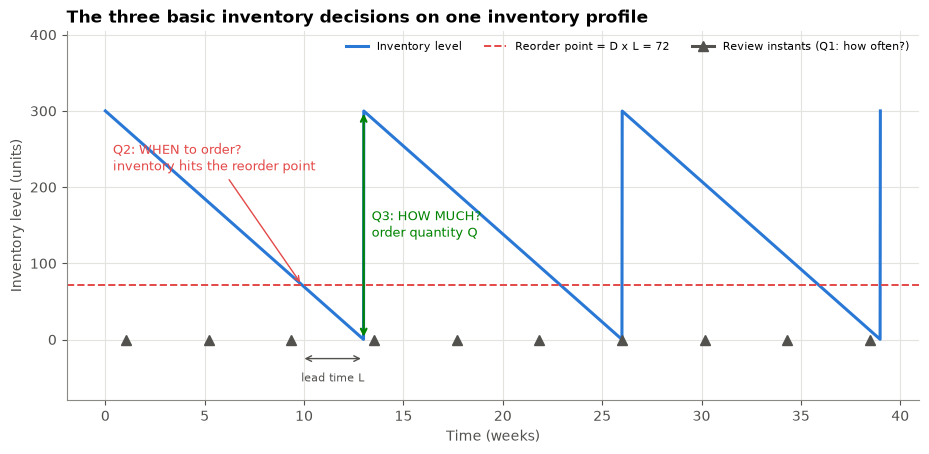

In [6]:
def fig_three_decisions():
    D, Q, L = 1200, 300, 0.06           # units/yr, units, lead time (years)
    t, I = inventory_profile(Q, D, 0.75)
    rop = D * L
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.plot(t * 52, I, color=C_ORDER, label="Inventory level")
    ax.axhline(rop, color=C_BAD, ls="--", lw=1.4, label=f"Reorder point = D x L = {rop:.0f}")
    # review instants
    for k, tr in enumerate(np.arange(0.02, 0.75, 0.08)):
        ax.plot([tr * 52], [0], marker="^", color=C_INK2, ms=7, clip_on=False, label="Review instants (Q1: how often?)" if k == 0 else None)
    T = Q / D
    t_order = T - L
    ax.annotate("Q2: WHEN to order?\ninventory hits the reorder point", xy=(t_order * 52, rop), xytext=(t_order * 52 - 9.5, rop + 150),
                arrowprops=dict(arrowstyle="->", color=C_BAD), color=C_BAD, fontsize=9)
    ax.annotate("", xy=(T * 52, Q), xytext=(T * 52, 0), arrowprops=dict(arrowstyle="<->", color=C_OPT, lw=1.6))
    ax.text(T * 52 + 0.4, Q / 2, "Q3: HOW MUCH?\norder quantity Q", color=C_OPT, fontsize=9, va="center")
    ax.annotate("", xy=(T * 52, -25), xytext=(t_order * 52, -25), arrowprops=dict(arrowstyle="<->", color=C_INK2))
    ax.text((t_order + L / 2) * 52, -55, "lead time L", ha="center", fontsize=8, color=C_INK2)
    ax.set_ylim(-80, Q * 1.25)
    ax.set_xlabel("Time (weeks)"); ax.set_ylabel("Inventory level (units)")
    ax.set_title("The three basic inventory decisions on one inventory profile")
    ax.legend(loc="upper right", ncol=3, fontsize=8)
    ax.set_ylim(-80, Q * 1.35)
    return fig

fig_three_decisions(); plt.show()

<a id="s2"></a>
## 2. Deterministic single-item models  📘 (slide 3)

* **Deterministic:** all problem parameters, *including demand*, are known in advance.
* The model is applied to a **single item at a single stocking location**.
* In a multi-item system a single-item model is **applied separately to each item** and **does not account for coordination among items** (for example ordering several items from the same supplier together). The industrial tool in Section 14 works this way: it loops over the item list.

> 💡 **Why study a "too simple" model?** Real demand is never perfectly known. As Section 9 shows, the EOQ cost curve is very **flat** near its minimum, so a model built on approximate data still gives near-optimal decisions. This robustness explains why the EOQ, published over 100 years ago, is still built into every ERP system.

<a id="s3"></a>
## 3. The EOQ model (Harris 1913, Wilson 1934) and its assumptions  📘 (slides 4–7)

The EOQ is the **earliest quantitative inventory model**. Its core is a **trade-off**:

* ordering cost versus inventory carrying cost, or equivalently
* order frequency versus average inventory level.

You need to understand the assumptions to avoid misusing the model:

| # | Assumption | What happens if it is violated | Relaxed in this lecture? |
|:-:|---|---|---|
| 1 | Demand rate is **constant and deterministic** | cost curve shifts over time, cycles become irregular | – (later: time-varying demand, safety stock) |
| 2 | Q need **not be an integer**; **no min/max** restriction on Q | rounding or limits needed | ✔ Tool: pack size, MOQ, max qty |
| 3 | Unit variable cost **does not depend on Q** (no discounts) | purchase cost vD depends on Q | ✔ **Section 11: quantity discounts** |
| 4 | Cost factors do not change appreciably with time (low inflation) | optimum drifts | – |
| 5 | Item is treated **independently** of other items | coordination savings are missed | – (joint replenishment) |
| 6 | Replenishment lead time is **zero**; a known nonzero lead time "creates no problem" | order must be placed L time units earlier | ✔ reorder point = D·L (Sections 1, 14) |
| 7 | **No shortages** allowed | – | – |
| 8 | The **entire order is delivered at the same time** | inventory builds up gradually | ✔ **Section 10: EPQ** |
| 9 | **Planning horizon is very long** (parameters stay the same for a long time) | end-of-horizon effects | – |

### 🎛️ Quick practical check of assumption 1: is my demand "approximately level"?
A common screening rule is to look at the **coefficient of variation (CV)** of period demand and at trend or seasonality. Compare a level-demand item with a seasonal one:

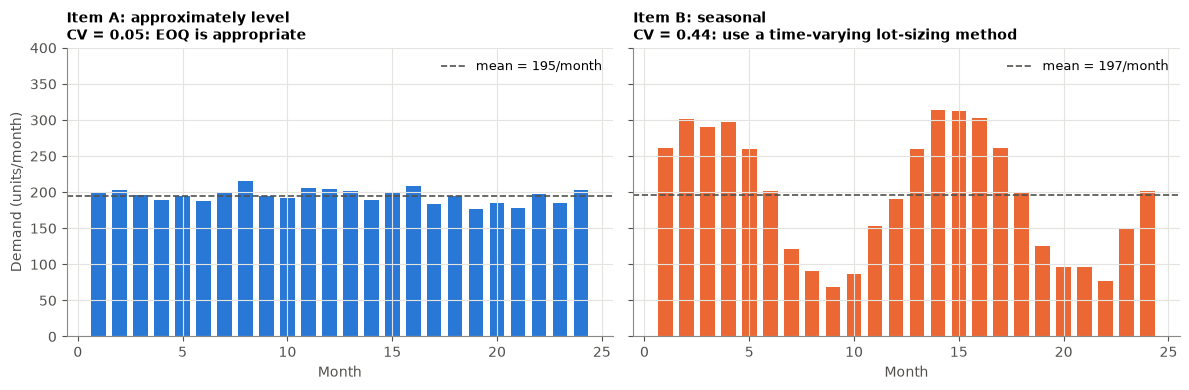

In [7]:
rng = np.random.default_rng(7)
months = np.arange(1, 25)
level = 200 + rng.normal(0, 12, 24)                                   # approximately level
seasonal = 200 + 120 * np.sin(2 * np.pi * months / 12) + rng.normal(0, 12, 24)  # strongly seasonal

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, series, name, col in zip(axes, [level, seasonal], ["Item A: approximately level", "Item B: seasonal"], [C_ORDER, C_CARRY]):
    cv = series.std(ddof=1) / series.mean()
    ax.bar(months, series, color=col, width=0.7)
    ax.axhline(series.mean(), color=C_INK2, ls="--", lw=1.2, label=f"mean = {series.mean():.0f}/month")
    verdict = "EOQ is appropriate" if cv < 0.2 else "use a time-varying lot-sizing method"
    ax.set_title(f"{name}\nCV = {cv:.2f}: {verdict}", fontsize=10)
    ax.set_xlabel("Month"); ax.legend(loc="upper right"); ax.set_ylim(0, 400)
axes[0].set_ylabel("Demand (units/month)")
plt.tight_layout(); plt.show()

<a id="s4"></a>
## 4. Notation and the inventory sawtooth  📘📊 (slides 8–10)

| Symbol | Meaning | Unit |
|:-:|---|---|
| $Q$ | replenishment order quantity | units |
| $A$ | ordering cost, **independent of order size** | \$/order |
| $v$ | unit variable cost: value of the item, including raw materials and value added through processing/assembly | \$/unit |
| $r$ | carrying charge: cost of having one dollar of the item tied up in inventory for one unit of time | \$/\$/unit time |
| $D$ | demand rate | units/unit time |
| $TRC(Q)$ | total relevant cost | \$/unit time |
| $Q/D$ | time between replenishments (cycle length) | time |
| $D/Q$ | number of orders placed per unit time (usually per year) | orders/time |
| $A+Qv$ | cost of one replenishment | \$ |

Because demand is constant and delivery is instantaneous, inventory drops linearly from $Q$ to $0$ at slope $-D$, and is then instantly refilled. The result is the **sawtooth** below.

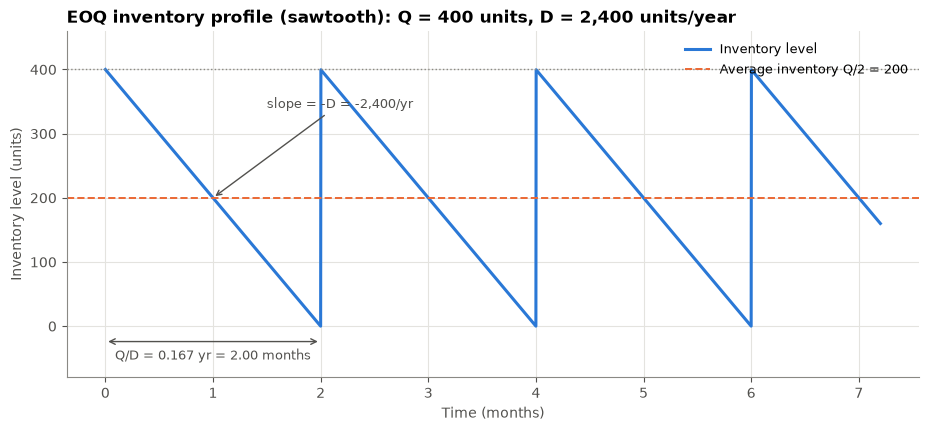

In [8]:
def plot_sawtooth(Q=400, D=2400, horizon=0.6, ax=None, show_avg=True, color=C_ORDER, label="Inventory level", annotate=True):
    t, I = inventory_profile(Q, D, horizon)
    ax = ax or plt.subplots(figsize=(11, 4.5))[1]
    ax.plot(t * 12, I, color=color, label=label)
    if show_avg:
        ax.axhline(Q / 2, color=C_CARRY, ls="--", lw=1.4, label=f"Average inventory Q/2 = {Q/2:,.0f}")
    ax.axhline(Q, color=C_MUTED, ls=":", lw=1)
    if annotate:
        T = Q / D * 12
        ax.annotate("", xy=(T, -0.06 * Q), xytext=(0, -0.06 * Q), arrowprops=dict(arrowstyle="<->", color=C_INK2))
        ax.text(T / 2, -0.13 * Q, f"Q/D = {Q/D:.3f} yr = {T:.2f} months", ha="center", fontsize=9, color=C_INK2)
        ax.annotate(f"slope = -D = -{D:,.0f}/yr", xy=(T * 0.5, Q * 0.5), xytext=(T * 0.75, Q * 0.85),
                    arrowprops=dict(arrowstyle="->", color=C_INK2), fontsize=9, color=C_INK2)
    ax.set_ylim(-0.2 * Q, Q * 1.15)
    ax.set_xlabel("Time (months)"); ax.set_ylabel("Inventory level (units)")
    ax.legend(loc="upper right")
    return ax

ax = plot_sawtooth(Q=400, D=2400)
ax.set_title("EOQ inventory profile (sawtooth): Q = 400 units, D = 2,400 units/year")
plt.show()

### 🎛️ Interactive demo 1: the sawtooth
Move **Q** and **D** and watch the cycle length $Q/D$, the number of orders $D/Q$ and the average inventory $Q/2$ change.
*Ask the class:* if we double Q, what happens to the average inventory? What happens to the number of orders?

In [9]:
def demo_sawtooth(Q=400, D=2400, horizon_months=12):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    plot_sawtooth(Q, D, horizon_months / 12, ax=ax, annotate=False)
    ax.set_title(f"Q = {Q:,.0f}  |  D = {D:,.0f}/yr  ->  cycle Q/D = {12*Q/D:.2f} months,  "
                 f"orders/yr D/Q = {D/Q:.1f},  average inventory = {Q/2:,.0f}")
    ax.set_xlim(0, horizon_months); ax.set_ylim(0, 2100)
    plt.show()

if HAS_WIDGETS:
    ui = w.interactive(demo_sawtooth,
                       Q=w.IntSlider(value=400, min=50, max=2000, step=25, description="Q (units)", continuous_update=False),
                       D=w.IntSlider(value=2400, min=600, max=12000, step=200, description="D (units/yr)", continuous_update=False),
                       horizon_months=w.IntSlider(value=12, min=3, max=24, description="Horizon (mo)", continuous_update=False))
    display(ui)
else:
    demo_sawtooth()

interactive(children=(IntSlider(value=400, continuous_update=False, description='Q (units)', max=2000, min=50,…

<a id="s5"></a>
## 5. Cost components and the total relevant cost  📘📊 (slides 9–12)

**Replenishment cost per unit time.** Each replenishment costs $A+Qv$, and one happens every $Q/D$ time units:
$$C_r=\frac{A+Qv}{Q/D}=\frac{AD}{Q}+vD$$

**Carrying cost per unit time.** The average inventory is $\bar I = Q/2$ units, each worth $v$ and charged at rate $r$:
$$C_c=\bar I\,v\,r=\frac{Q\,v\,r}{2}$$

**Total relevant cost.** The term $vD$ does not depend on $Q$, so it is omitted:
$$\boxed{TRC(Q)=C_c+C_r-vD=\frac{Q\,v\,r}{2}+\frac{A\,D}{Q}}$$

### 🧮 Lecture example data (`data/ex1_eoq_basic.csv`)
The lecture figure (slide 12) has its minimum at $Q=400$. The data below reproduce it exactly.

In [10]:
ex1 = pd.read_csv(os.path.join(DATA_DIR, "ex1_eoq_basic.csv"))
display(ex1)
P1 = dict(zip(ex1["symbol"], ex1["value"]))
A, D, v, r = P1["A"], P1["D"], P1["v"], P1["r"]
print(f"A = ${A}/order,  D = {D:,.0f} units/yr,  v = ${v}/unit,  r = {r}/yr")

,parameter,symbol,value,unit,description
0,annual_demand,D,2400.00,units/year,Demand rate of the item (constant and determin...
1,ordering_cost,A,3.20,$/order,Fixed cost per replenishment order (independen...
2,unit_cost,v,0.40,$/unit,Unit variable cost (value of the item)
3,carrying_rate,r,0.24,$/$/year,Cost of holding one dollar of inventory for on...


A = $3.2/order,  D = 2,400 units/yr,  v = $0.4/unit,  r = 0.24/yr


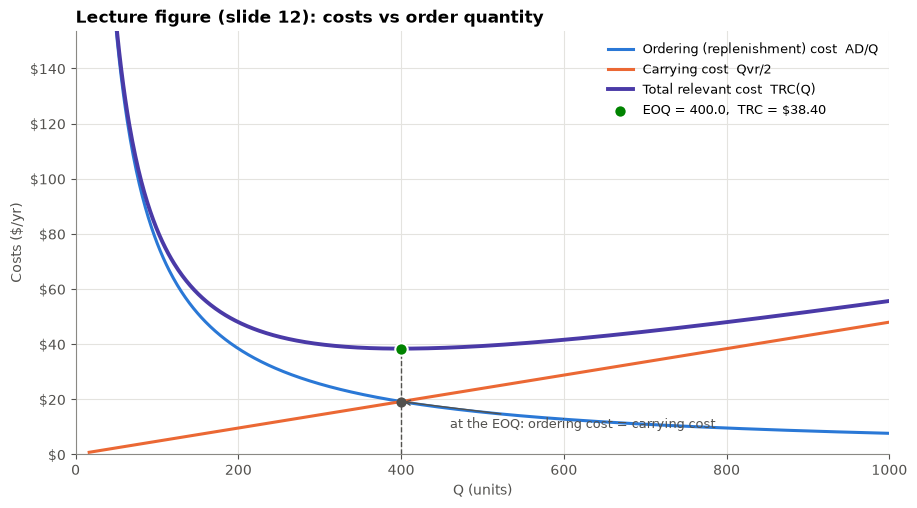

Q,Orders/yr D/Q,Ordering AD/Q ($),Avg inv Q/2,Carrying Qvr/2 ($),TRC ($)
50,48.0,153.60,25,2.40,156.00
100,24.0,76.80,50,4.80,81.60
200,12.0,38.40,100,9.60,48.00
300,8.0,25.60,150,14.40,40.00
400,6.0,19.20,200,19.20,38.40
500,4.8,15.36,250,24.00,39.36
600,4.0,12.80,300,28.80,41.60
800,3.0,9.60,400,38.40,48.00
1000,2.4,7.68,500,48.00,55.68


In [11]:
def plot_cost_curves(A, D, v, r, Q_max=None, Q_mark=None, ax=None, title=None):
    Qs = eoq(A, D, v, r)
    Q_max = Q_max or 2.5 * Qs
    Q = np.linspace(Q_max / 60, Q_max, 800)
    ax = ax or plt.subplots(figsize=(10.5, 5.5))[1]
    ax.plot(Q, A * D / Q, color=C_ORDER, label="Ordering (replenishment) cost  AD/Q")
    ax.plot(Q, Q * v * r / 2, color=C_CARRY, label="Carrying cost  Qvr/2")
    ax.plot(Q, trc(Q, A, D, v, r), color=C_TOTAL, lw=2.8, label="Total relevant cost  TRC(Q)")
    T = trc(Qs, A, D, v, r)
    ax.vlines(Qs, 0, T, colors=C_INK2, linestyles="--", lw=1)
    ax.scatter([Qs], [T], s=80, color=C_OPT, zorder=5, edgecolor="white", lw=1.5, label=f"EOQ = {Qs:,.1f},  TRC = ${T:,.2f}")
    ax.scatter([Qs], [T / 2], s=40, color=C_INK2, zorder=5)
    ax.annotate("at the EOQ: ordering cost = carrying cost", xy=(Qs, T / 2), xytext=(Qs * 1.15, T * 0.25),
                arrowprops=dict(arrowstyle="->", color=C_INK2), fontsize=9, color=C_INK2)
    if Q_mark is not None:
        ax.scatter([Q_mark], [trc(Q_mark, A, D, v, r)], s=80, marker="X", color=C_BAD, zorder=6,
                   label=f"Q = {Q_mark:,.0f}: TRC = ${trc(Q_mark, A, D, v, r):,.2f}")
    ax.set_ylim(0, 4 * T); ax.set_xlim(0, Q_max)
    ax.set_xlabel("Q (units)"); ax.set_ylabel("Costs ($/yr)")
    ax.yaxis.set_major_formatter(money)
    ax.set_title(title or "Cost trade-off: ordering vs carrying")
    ax.legend(loc="upper right")
    return ax

plot_cost_curves(A, D, v, r, Q_max=1000, title="Lecture figure (slide 12): costs vs order quantity")
plt.show()

# Cost table at several order sizes
Qgrid = [50, 100, 200, 300, 400, 500, 600, 800, 1000]
tbl = pd.DataFrame({"Q": Qgrid,
                    "Orders/yr D/Q": [D / q for q in Qgrid],
                    "Ordering AD/Q ($)": [A * D / q for q in Qgrid],
                    "Avg inv Q/2": [q / 2 for q in Qgrid],
                    "Carrying Qvr/2 ($)": [q * v * r / 2 for q in Qgrid],
                    "TRC ($)": [trc(q, A, D, v, r) for q in Qgrid]})
display(tbl.style.format({"Orders/yr D/Q": "{:.1f}", "Ordering AD/Q ($)": "{:.2f}", "Avg inv Q/2": "{:.0f}",
                          "Carrying Qvr/2 ($)": "{:.2f}", "TRC ($)": "{:.2f}"})
          .highlight_min(subset=["TRC ($)"], color="#d9f2e6").hide(axis="index"))

### 📊 Where the money goes: stacked view of TRC(Q)
Stacking the two components shows that moving away from the EOQ in either direction raises the total, and that the rise is much steeper when **Q is too small** (too many orders) than when it is too large.

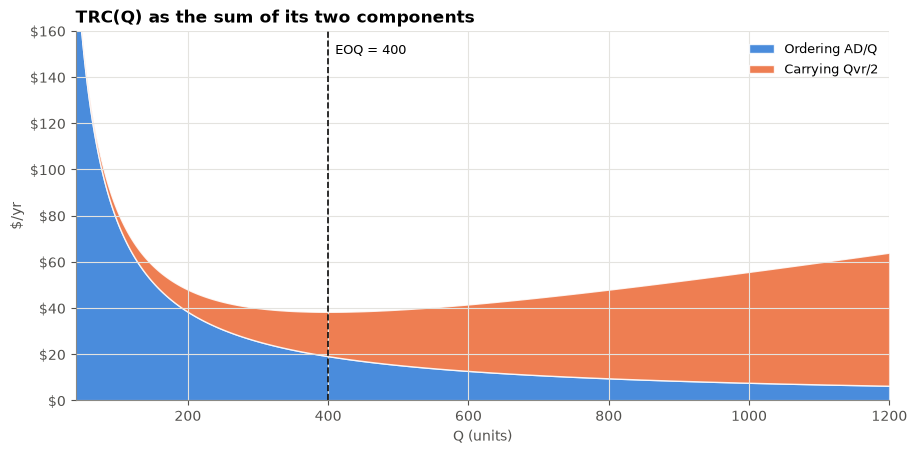

In [12]:
Q = np.linspace(40, 1200, 600)
fig, ax = plt.subplots(figsize=(10.5, 4.8))
ax.stackplot(Q, A * D / Q, Q * v * r / 2, colors=[C_ORDER, C_CARRY], alpha=0.85,
             labels=["Ordering AD/Q", "Carrying Qvr/2"], edgecolor="white", linewidth=1)
Qs = eoq(A, D, v, r)
ax.axvline(Qs, color=C_INK, ls="--", lw=1.2); ax.text(Qs + 10, 150, f"EOQ = {Qs:.0f}", fontsize=9)
ax.set_ylim(0, 160); ax.set_xlim(40, 1200)
ax.set_xlabel("Q (units)"); ax.set_ylabel("$/yr"); ax.yaxis.set_major_formatter(money)
ax.set_title("TRC(Q) as the sum of its two components"); ax.legend(loc="upper right")
plt.show()

### 🎛️ Interactive demo 2: cost trade-off explorer (with PDF export)
Change the parameters and the order quantity you would actually use. Things to try in class:
* Increase **A** (for example a new, bureaucratic purchasing process): the EOQ grows, with the **square root** of A.
* Increase **r** (interest rates rise): the EOQ shrinks.
* Put **Q** at half the EOQ and then at double the EOQ. Which penalty is larger?

The **Export PDF** button writes a report of the scenario on screen to `reports/`.

In [13]:
def eoq_scenario_figure(A, D, v, r, Q_used):
    Qs = eoq(A, D, v, r)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw=dict(width_ratios=[1.6, 1]))
    plot_cost_curves(A, D, v, r, Q_max=max(2.5 * Qs, 1.3 * Q_used), Q_mark=Q_used, ax=axes[0],
                     title=f"TRC(Q):  EOQ = {Qs:,.1f}")
    labels = ["EOQ", "Q used"]
    ordc = [A * D / Qs, A * D / Q_used]; carc = [Qs * v * r / 2, Q_used * v * r / 2]
    axes[1].bar(labels, ordc, color=C_ORDER, width=0.5, label="Ordering")
    axes[1].bar(labels, carc, bottom=ordc, color=C_CARRY, width=0.5, label="Carrying")
    for i in range(2):
        axes[1].text(i, ordc[i] + carc[i], f"${ordc[i]+carc[i]:,.2f}", ha="center", va="bottom", fontsize=10, weight="bold")
    axes[1].set_title(f"Cost components   (PCP of Q used = {float(pcp(Q_used/Qs-1)):.2f}%)")
    axes[1].yaxis.set_major_formatter(money2); axes[1].legend(loc="upper left")
    axes[1].set_ylim(0, max(o + c for o, c in zip(ordc, carc)) * 1.25); axes[1].grid(axis="x", visible=False)
    plt.tight_layout()
    return fig

def export_eoq_report(A, D, v, r, Q_used=None, name="EOQ_solution", title="EOQ Solution Report"):
    """Full EOQ solution + charts to reports/<name>.pdf"""
    Qs = eoq(A, D, v, r)
    Q_used = Q_used if Q_used is not None else round(Qs)
    sol = solve_eoq(A, D, v, r, Q_used=Q_used)
    rep = PDFReport(os.path.join(REPORT_DIR, f"{name}.pdf"), title, f"A = ${A:g}, D = {D:,.0f}/yr, v = ${v:g}, r = {r:g}")
    rep.text("1. Model and formulas", [
        "## Inputs",
        f"Ordering cost A = ${A:,.2f}/order;  demand D = {D:,.0f} units/yr;  unit cost v = ${v:,.3f};  carrying charge r = {r:.3f} $/$/yr.",
        "## Total relevant cost",
        r"$TRC(Q)=\frac{Qvr}{2}+\frac{AD}{Q}$",
        "## Optimal order quantity (Wilson formula)",
        r"$EOQ=\sqrt{\frac{2AD}{vr}}$" + f"$\\ = \\sqrt{{\\frac{{2({A:g})({D:g})}}{{({v:g})({r:g})}}}} = {Qs:,.2f}$",
        r"$TRC(EOQ)=\sqrt{2ADvr}$" + f"$\\ = {np.sqrt(2*A*D*v*r):,.2f}$ \\$/yr",
        "## Other expressions",
        r"$T_{EOQ}=\sqrt{\frac{288A}{Dvr}}$" + f"$\\ = {sol['T_EOQ (months of supply)']:.3f}$ months;   " + r"$TR=\sqrt{\frac{2vrD}{A}}$" + f"$\\ = {sol['Turnover ratio TR = D/I_bar']:.2f}$",
        "## Sensitivity",
        r"$PCP = 50\,\frac{\alpha^2}{1+\alpha},\quad Q'=(1+\alpha)EOQ$",
        f"Using Q' = {Q_used:,.0f} (alpha = {Q_used/Qs-1:+.3f}) gives PCP = {float(pcp(Q_used/Qs-1)):.3f}%.",
    ])
    rep.table(sol, "2. Numerical results")
    rep.figure(eoq_scenario_figure(A, D, v, r, Q_used), "Left: cost curves. Right: components at the EOQ and at the Q used.")
    fig, ax = plt.subplots(figsize=(11, 4.5)); plot_sawtooth(Qs, D, max(3 * Qs / D, 0.25), ax=ax)
    ax.set_title("Inventory profile at the EOQ"); rep.figure(fig)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    al = np.linspace(-0.6, 1.0, 400); ax.plot(al * 100, pcp(al), color=C_TOTAL)
    ax.scatter([(Q_used / Qs - 1) * 100], [pcp(Q_used / Qs - 1)], color=C_BAD, s=70, zorder=5, label="Q used")
    ax.set_xlabel("Percent deviation from EOQ (%)"); ax.set_ylabel("PCP (%)"); ax.legend()
    ax.set_title("Percentage cost penalty curve"); rep.figure(fig)
    return rep.close()

def demo_costs(A=3.2, D=2400, v=0.40, r=0.24, Q_used=400):
    eoq_scenario_figure(A, D, v, r, Q_used); plt.show()
    s = solve_eoq(A, D, v, r, Q_used)
    print(f"EOQ = {s['EOQ (units)']:,.2f} | TRC(EOQ) = ${s['TRC(EOQ) ($/yr)']:,.2f} | orders/yr = {s['Orders per year D/Q']:.2f} | "
          f"T = {s['T_EOQ (months of supply)']:.2f} months | TR = {s['Turnover ratio TR = D/I_bar']:.2f} | "
          f"TRC(Q used) = ${s['TRC(Q used) ($/yr)']:,.2f} | PCP = {s['PCP of Q used (%)']:.2f}%")

if HAS_WIDGETS:
    sA = w.FloatSlider(value=3.2, min=0.5, max=50, step=0.1, description="A ($/order)", continuous_update=False)
    sD = w.IntSlider(value=2400, min=100, max=20000, step=100, description="D (units/yr)", continuous_update=False)
    sv = w.FloatSlider(value=0.40, min=0.05, max=10, step=0.05, description="v ($/unit)", continuous_update=False)
    sr = w.FloatSlider(value=0.24, min=0.05, max=0.6, step=0.01, description="r (1/yr)", continuous_update=False)
    sQ = w.IntSlider(value=400, min=10, max=4000, step=10, description="Q used", continuous_update=False)
    out2 = w.interactive_output(demo_costs, dict(A=sA, D=sD, v=sv, r=sr, Q_used=sQ))
    btn2 = w.Button(description="📄 Export PDF", button_style="primary")
    msg2 = w.Output()
    def _exp2(_):
        with msg2:
            msg2.clear_output()
            export_eoq_report(sA.value, sD.value, sv.value, sr.value, sQ.value, name="EOQ_scenario_from_widget",
                              title="EOQ Scenario Report")
    btn2.on_click(_exp2)
    display(w.VBox([w.HBox([w.VBox([sA, sD]), w.VBox([sv, sr]), w.VBox([sQ, btn2])]), out2, msg2]))
else:
    demo_costs()

<a id="s6"></a>
## 6. Derivation of the EOQ and the total cost at the EOQ  📘 (slides 13–14)

The optimal Q is found from the **necessary condition** that the slope (derivative) of $TRC(Q)$ is zero at the minimum:
$$\frac{dTRC(Q)}{dQ}=\frac{vr}{2}-\frac{AD}{Q^2}=0\quad\Longrightarrow\quad \boxed{EOQ=\sqrt{\frac{2AD}{vr}}}\ \ \text{(Wilson formula)}$$

Substituting back:
$$TRC(EOQ)=\sqrt{\tfrac{ADvr}{2}}+\sqrt{\tfrac{ADvr}{2}}=\boxed{\sqrt{2ADvr}}$$

The cell below lets **`sympy`** carry out the same algebra step by step. It also checks the **sufficient condition** (second derivative > 0), which the slides do not show.

In [14]:
Qs_, A_, D_, v_, r_ = sp.symbols("Q A D v r", positive=True)
TRC_ = Qs_ * v_ * r_ / 2 + A_ * D_ / Qs_
display(Markdown("**1. Total relevant cost**"), sp.Eq(sp.Symbol("TRC(Q)"), TRC_))

dTRC = sp.diff(TRC_, Qs_)
display(Markdown("**2. First derivative (slope)**"), sp.Eq(sp.Symbol("dTRC/dQ"), dTRC))

sol = sp.solve(sp.Eq(dTRC, 0), Qs_)
EOQ_ = sol[0]
display(Markdown("**3. Set the slope to zero and solve for Q (Wilson formula)**"), sp.Eq(sp.Symbol("EOQ"), EOQ_))

d2 = sp.simplify(sp.diff(TRC_, Qs_, 2))
display(Markdown("**4. Second derivative: always positive for Q > 0, so the stationary point is a minimum**"),
        sp.Eq(sp.Symbol("d^2TRC/dQ^2"), d2))

TRC_opt = sp.simplify(TRC_.subs(Qs_, EOQ_))
display(Markdown("**5. Total relevant cost at the EOQ**"), sp.Eq(sp.Symbol("TRC(EOQ)"), TRC_opt))

cc, co = sp.simplify((Qs_ * v_ * r_ / 2).subs(Qs_, EOQ_)), sp.simplify((A_ * D_ / Qs_).subs(Qs_, EOQ_))
display(Markdown("**6. Carrying and ordering cost at the EOQ are equal**"), sp.Eq(cc, co))
print("Numerical check with the lecture data:  EOQ =", float(EOQ_.subs({A_: A, D_: D, v_: v, r_: r})),
      "  TRC(EOQ) =", float(TRC_opt.subs({A_: A, D_: D, v_: v, r_: r})))

**1. Total relevant cost**

Eq(TRC(Q), A*D/Q + Q*r*v/2)

**2. First derivative (slope)**

Eq(dTRC/dQ, -A*D/Q**2 + r*v/2)

**3. Set the slope to zero and solve for Q (Wilson formula)**

...

**5. Total relevant cost at the EOQ**

Eq(TRC(EOQ), sqrt(2)*sqrt(A)*sqrt(D)*sqrt(r)*sqrt(v))

**6. Carrying and ordering cost at the EOQ are equal**

True

Numerical check with the lecture data:  EOQ = 400.0   TRC(EOQ) = 38.4


### 📊 Visualising the optimality condition
Left: the tangent to $TRC(Q)$ is horizontal only at the EOQ. Right: the derivative $vr/2 - AD/Q^2$ crosses zero exactly at the EOQ. It is negative before (increasing Q lowers the cost) and positive after.

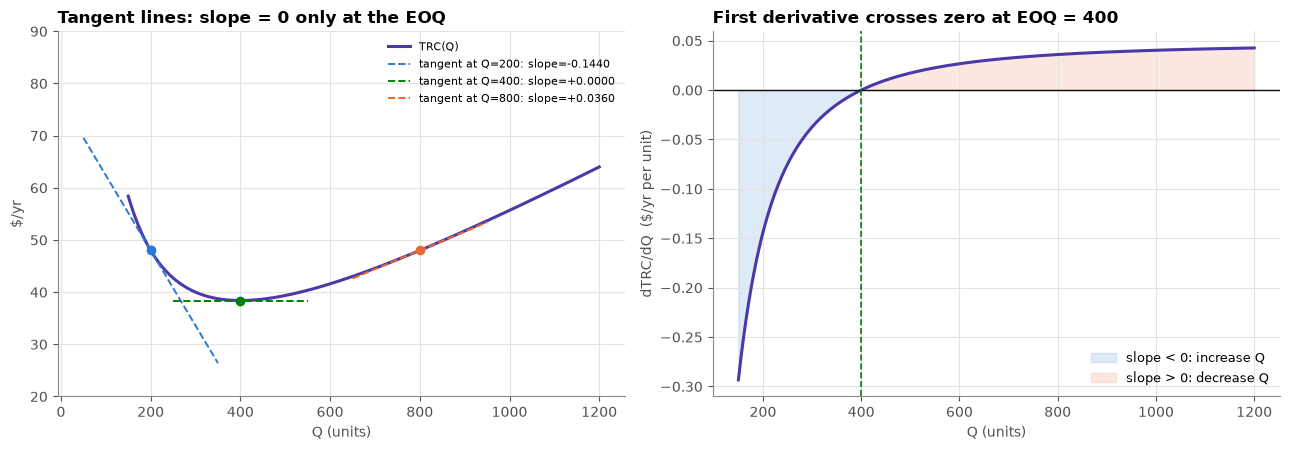

In [15]:
Qs = eoq(A, D, v, r)
Q = np.linspace(150, 1200, 600)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]; ax.plot(Q, trc(Q, A, D, v, r), color=C_TOTAL, label="TRC(Q)")
for q0, col in [(200, C_ORDER), (Qs, C_OPT), (800, C_CARRY)]:
    slope = v * r / 2 - A * D / q0 ** 2
    qq = np.linspace(q0 - 150, q0 + 150, 10)
    ax.plot(qq, trc(q0, A, D, v, r) + slope * (qq - q0), color=col, lw=1.4, ls="--",
            label=f"tangent at Q={q0:.0f}: slope={slope:+.4f}")
    ax.scatter([q0], [trc(q0, A, D, v, r)], color=col, zorder=5)
ax.set_ylim(20, 90); ax.set_xlabel("Q (units)"); ax.set_ylabel("$/yr"); ax.legend(fontsize=8)
ax.set_title("Tangent lines: slope = 0 only at the EOQ")
ax = axes[1]
ax.plot(Q, v * r / 2 - A * D / Q ** 2, color=C_TOTAL)
ax.axhline(0, color=C_INK, lw=1); ax.axvline(Qs, color=C_OPT, ls="--", lw=1.2)
ax.fill_between(Q, v * r / 2 - A * D / Q ** 2, 0, where=Q < Qs, color=C_ORDER, alpha=0.15, label="slope < 0: increase Q")
ax.fill_between(Q, v * r / 2 - A * D / Q ** 2, 0, where=Q > Qs, color=C_CARRY, alpha=0.15, label="slope > 0: decrease Q")
ax.set_xlabel("Q (units)"); ax.set_ylabel("dTRC/dQ  ($/yr per unit)"); ax.legend()
ax.set_title(f"First derivative crosses zero at EOQ = {Qs:.0f}")
plt.tight_layout(); plt.show()

<a id="s7"></a>
## 7. Other expressions of the EOQ  📘📊 (slides 15–16)

**EOQ in months of demand it satisfies:**
$$T_{EOQ}=\frac{EOQ}{D/12}=12\,\frac{EOQ}{D}=12\sqrt{\frac{2AD}{D^2vr}}=\boxed{\sqrt{\frac{288A}{Dvr}}}$$

**Turnover ratio**, annual demand divided by the average inventory:
$$TR=\frac{D}{\bar I}=\frac{D}{EOQ/2}=2D\sqrt{\frac{vr}{2AD}}=\boxed{\sqrt{\frac{2vrD}{A}}}$$

> 💡 **Key insight:** both expressions depend on the **annual dollar usage $Dv$**. Items with high dollar usage should be ordered **more often** (short $T$) and turn over **faster** (high TR). This is the reason behind ABC classification.

Lecture example:  EOQ = 400 units
  T_EOQ = 12*EOQ/D = 12*400/2400 = 2.000 months   | sqrt(288A/(Dvr)) = 2.000 months
  TR = D/(EOQ/2) = 12.000 turns/yr   | sqrt(2vrD/A) = 12.000


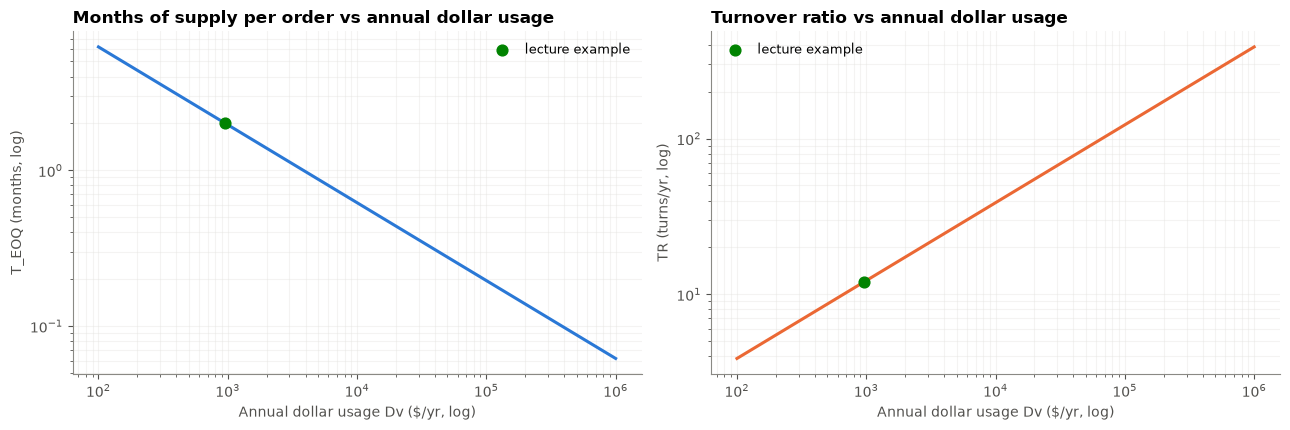

In [16]:
s = solve_eoq(A, D, v, r)
print(f"Lecture example:  EOQ = {s['EOQ (units)']:.0f} units")
print(f"  T_EOQ = 12*EOQ/D = 12*{s['EOQ (units)']:.0f}/{D:.0f} = {12*s['EOQ (units)']/D:.3f} months   "
      f"| sqrt(288A/(Dvr)) = {s['T_EOQ (months of supply)']:.3f} months")
print(f"  TR = D/(EOQ/2) = {D/(s['EOQ (units)']/2):.3f} turns/yr   | sqrt(2vrD/A) = {s['Turnover ratio TR = D/I_bar']:.3f}")

# How T_EOQ and TR scale with annual dollar usage Dv (A and r fixed)
Dv = np.logspace(2, 6, 200)                 # $100 to $1,000,000 per year
T_months = np.sqrt(288 * A / (Dv * r))
TR_ = np.sqrt(2 * r * Dv / A)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].loglog(Dv, T_months, color=C_ORDER); axes[0].set_title("Months of supply per order vs annual dollar usage")
axes[0].set_xlabel("Annual dollar usage Dv ($/yr, log)"); axes[0].set_ylabel("T_EOQ (months, log)")
axes[0].scatter([D * v], [s["T_EOQ (months of supply)"]], color=C_OPT, s=60, zorder=5, label="lecture example")
axes[0].legend()
axes[1].loglog(Dv, TR_, color=C_CARRY); axes[1].set_title("Turnover ratio vs annual dollar usage")
axes[1].set_xlabel("Annual dollar usage Dv ($/yr, log)"); axes[1].set_ylabel("TR (turns/yr, log)")
axes[1].scatter([D * v], [s["Turnover ratio TR = D/I_bar"]], color=C_OPT, s=60, zorder=5, label="lecture example")
axes[1].legend()
for ax in axes: ax.grid(True, which="both", alpha=0.4)
plt.tight_layout(); plt.show()

### 🎛️ Interactive demo 3: the EOQ landscape (square-root law)
The heat map shows the EOQ for every combination of **A** and **D** at a chosen $v$ and $r$. The contour lines are curves of equal EOQ. **Doubling D increases the EOQ by only $\sqrt2\approx1.41$**, so large-volume items get proportionally *smaller* order quantities relative to their demand.

In [17]:
def demo_landscape(v=0.40, r=0.24, show="EOQ (units)"):
    Ag = np.linspace(1, 100, 200); Dg = np.linspace(100, 20000, 200)
    AA, DD = np.meshgrid(Ag, Dg)
    Z = {"EOQ (units)": eoq(AA, DD, v, r), "T_EOQ (months)": np.sqrt(288 * AA / (DD * v * r)),
         "Turnover ratio": np.sqrt(2 * v * r * DD / AA)}[show]
    fig, ax = plt.subplots(figsize=(9, 6))
    pc = ax.pcolormesh(AA, DD, Z, cmap="Blues", shading="auto")
    cs = ax.contour(AA, DD, Z, levels=8, colors=C_INK, linewidths=0.8)
    ax.clabel(cs, fmt="%.0f" if show != "T_EOQ (months)" else "%.1f", fontsize=8)
    fig.colorbar(pc, ax=ax, label=show)
    ax.scatter([A], [D], color=C_CARRY, s=80, edgecolor="white", zorder=5, label="lecture example (A=3.2, D=2400)")
    ax.set_xlabel("Ordering cost A ($/order)"); ax.set_ylabel("Demand D (units/yr)")
    ax.set_title(f"{show} for v = ${v:.2f}, r = {r:.2f}"); ax.legend(loc="upper right")
    plt.show()

if HAS_WIDGETS:
    display(w.interactive(demo_landscape,
        v=w.FloatSlider(value=0.40, min=0.1, max=5, step=0.05, description="v ($)", continuous_update=False),
        r=w.FloatSlider(value=0.24, min=0.05, max=0.5, step=0.01, description="r", continuous_update=False),
        show=w.ToggleButtons(options=["EOQ (units)", "T_EOQ (months)", "Turnover ratio"], description="Show")))
else:
    demo_landscape()

interactive(children=(FloatSlider(value=0.4, continuous_update=False, description='v ($)', max=5.0, min=0.1, s…

<a id="s8"></a>
## 8. Worked example 1: complete EOQ solution and PDF report  🧮📄

**Problem** (data in `data/ex1_eoq_basic.csv`): an item has a demand of 2,400 units/year, an ordering cost of \$3.20 per order, a unit cost of \$0.40 and a carrying charge of 0.24 \$/\$/year. Find the EOQ, the total relevant cost, the time between orders, the number of orders per year, the average inventory and the turnover ratio. The buyer currently orders 600 units at a time. What does that cost the company?

**Solution by hand**
* $EOQ=\sqrt{2(3.2)(2400)/(0.40\times0.24)}=\sqrt{160000}=400$ units
* $TRC(EOQ)=\sqrt{2(3.2)(2400)(0.40)(0.24)}=\$38.40$/yr, split into \$19.20 ordering and \$19.20 carrying
* $D/Q=6$ orders/yr; $T_{EOQ}=12(400/2400)=2$ months; $\bar I=200$ units; $TR=2400/200=12$ turns/yr
* $Q'=600\Rightarrow\alpha=0.5\Rightarrow PCP=50(0.25)/1.5=8.33\%$, which costs \$3.20/yr more

In [18]:
sol1 = solve_eoq(A, D, v, r, Q_used=600)
show_dict(sol1, "Worked example 1: computed solution")
assert abs(sol1["EOQ (units)"] - 400) < 1e-9 and abs(sol1["TRC(EOQ) ($/yr)"] - 38.4) < 1e-9
print("✔ matches the hand calculation (EOQ = 400, TRC = $38.40)")

**Worked example 1: computed solution**

Quantity,Value
EOQ (units),400.0000
TRC(EOQ) ($/yr),38.4000
Ordering cost AD/Q ($/yr),19.2000
Carrying cost Qvr/2 ($/yr),19.2000
Purchase cost vD ($/yr),960.0000
Orders per year D/Q,6.0000
Time between orders Q/D (years),0.1667
T_EOQ (months of supply),2.0000
Time between orders (weeks),8.6667
Average inventory Q/2 (units),200.0000


✔ matches the hand calculation (EOQ = 400, TRC = $38.40)


In [19]:
# 📄 Export the complete solution with charts
export_eoq_report(A, D, v, r, Q_used=600, name="Example1_EOQ_Report", title="Worked Example 1: EOQ Solution")

PDF report saved: c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\reports\Example1_EOQ_Report.pdf  (6 pages)


'c:\\Users\\islam\\Documents\\GitHub\\IME452_InventoryManagementAndControl_FALL2026\\Lecture02\\reports\\Example1_EOQ_Report.pdf'

<a id="s9"></a>
## 9. Sensitivity analysis: the percentage cost penalty (PCP)  📘📊 (slide 17)

*What is the effect on TRC of using an order quantity $Q'$ that deviates from the EOQ by a fraction $\alpha$?*
$$Q'=(1+\alpha)\,EOQ,\qquad PCP=\frac{TRC(Q')-TRC(EOQ)}{TRC(EOQ)}\times100$$
$$\boxed{PCP=50\left(\frac{\alpha^2}{1+\alpha}\right)}$$

Derivation: $TRC(Q')/TRC(EOQ)=\tfrac12\left[(1+\alpha)+\tfrac{1}{1+\alpha}\right]$. `sympy` verifies it below.

In [20]:
al = sp.symbols("alpha", real=True)
Qp = (1 + al) * EOQ_
ratio = sp.simplify(TRC_.subs(Qs_, Qp) / TRC_opt)
display(Markdown("**TRC(Q') / TRC(EOQ)** (A, D, v and r cancel out, so the result holds for every item):"), ratio)
PCP_ = sp.simplify((ratio - 1) * 100)
display(Markdown("**PCP (%)**"), sp.Eq(sp.Symbol("PCP"), sp.factor(PCP_)))

**TRC(Q') / TRC(EOQ)** (A, D, v and r cancel out, so the result holds for every item):

((alpha + 1)**2 + 1)/(2*(alpha + 1))

**PCP (%)**

Eq(PCP, 50*alpha**2/(alpha + 1))

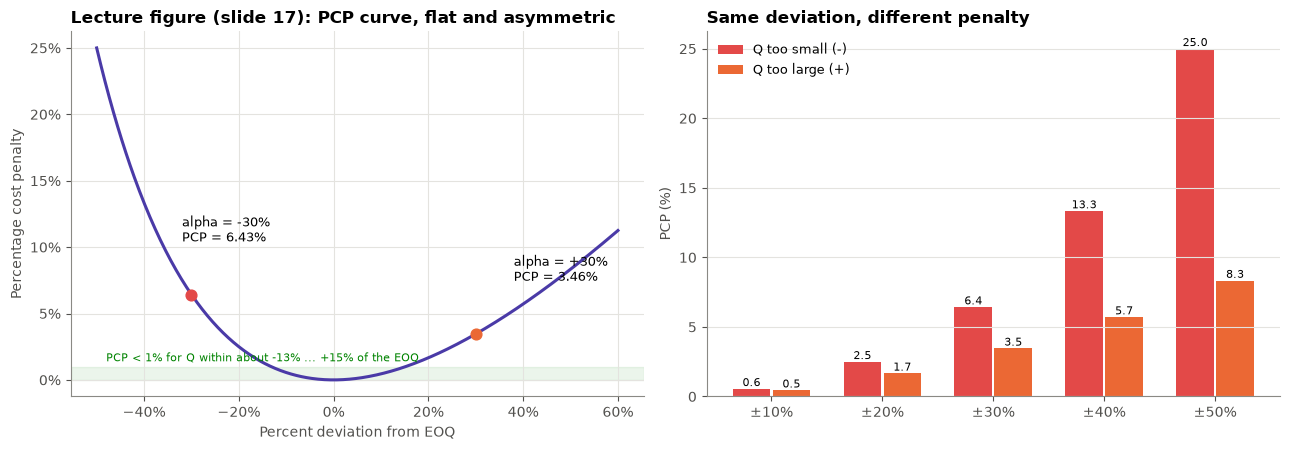

alpha,Q'/EOQ,PCP (%)
-50%,0.50,25.00
-30%,0.70,6.43
-20%,0.80,2.50
-10%,0.90,0.56
+0%,1.00,0.00
+10%,1.10,0.45
+20%,1.20,1.67
+30%,1.30,3.46
+50%,1.50,8.33
+100%,2.00,25.00


In [21]:
alpha = np.linspace(-0.5, 0.6, 500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ax = axes[0]
ax.plot(alpha * 100, pcp(alpha), color=C_TOTAL)
for a0 in (-0.3, 0.3):
    ax.scatter([a0 * 100], [pcp(a0)], color=C_BAD if a0 < 0 else C_CARRY, s=60, zorder=5)
    ax.annotate(f"alpha = {a0:+.0%}\nPCP = {float(pcp(a0)):.2f}%", xy=(a0 * 100, pcp(a0)),
                xytext=(a0 * 100 + (8 if a0 > 0 else -2), pcp(a0) + 4), fontsize=9)
ax.axhspan(0, 1, color=C_OPT, alpha=0.08); ax.text(-48, 1.4, "PCP < 1% for Q within about -13% ... +15% of the EOQ", fontsize=8, color=C_OPT)
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0)); ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
ax.set_xlabel("Percent deviation from EOQ"); ax.set_ylabel("Percentage cost penalty")
ax.set_title("Lecture figure (slide 17): PCP curve, flat and asymmetric")

# symmetric comparison: ordering too little is worse than ordering too much
dev = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
x = np.arange(len(dev))
axes[1].bar(x - 0.18, pcp(-dev), 0.34, color=C_BAD, label="Q too small (-)")
axes[1].bar(x + 0.18, pcp(dev), 0.34, color=C_CARRY, label="Q too large (+)")
axes[1].set_xticks(x, [f"±{d:.0%}" for d in dev]); axes[1].set_ylabel("PCP (%)")
axes[1].set_title("Same deviation, different penalty"); axes[1].legend(); axes[1].grid(axis="x", visible=False)
for i, d0 in enumerate(dev):
    axes[1].text(i - 0.18, pcp(-d0), f"{float(pcp(-d0)):.1f}", ha="center", va="bottom", fontsize=8)
    axes[1].text(i + 0.18, pcp(d0), f"{float(pcp(d0)):.1f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout(); plt.show()

pcp_table = pd.DataFrame({"alpha": [-0.5, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.3, 0.5, 1.0]})
pcp_table["Q'/EOQ"] = 1 + pcp_table["alpha"]; pcp_table["PCP (%)"] = pcp(pcp_table["alpha"])
display(pcp_table.style.format({"alpha": "{:+.0%}", "Q'/EOQ": "{:.2f}", "PCP (%)": "{:.2f}"}).hide(axis="index"))

### 🧮 Real policies judged with the PCP (`data/ex4_sensitivity_scenarios.csv`)
Practical order quantities for the lecture item (EOQ = 400): pack sizes, rules of thumb and so on. How much do they cost?

scenario,Q_used,reason,alpha,PCP (%),TRC ($/yr),Extra cost ($/yr)
Order exactly the EOQ,400,Benchmark,+0.0%,0.00,38.40,0.00
Supplier ships in cases of 250,250,Pack-size rounding down,-37.5%,11.25,42.72,4.32
Supplier ships in cases of 500,500,Pack-size rounding up,+25.0%,2.50,39.36,0.96
Buyer orders one month of demand,200,Rule-of-thumb policy,-50.0%,25.00,48.00,9.60
Buyer orders one quarter of demand,600,Rule-of-thumb policy,+50.0%,8.33,41.60,3.20
Warehouse orders half a year at a time,1200,Large infrequent orders,+200.0%,66.67,64.00,25.60
Buyer orders weekly,46,Very frequent small orders,-88.5%,340.53,169.16,130.76


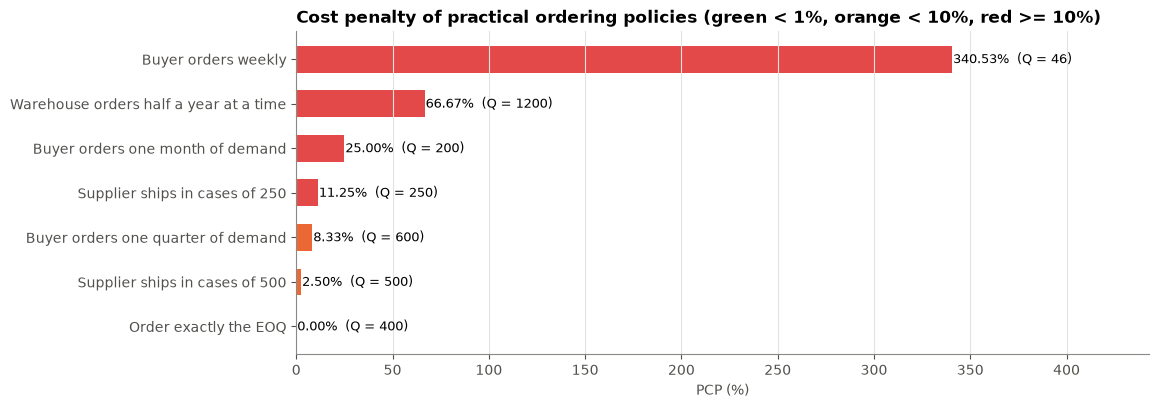

In [22]:
sc = pd.read_csv(os.path.join(DATA_DIR, "ex4_sensitivity_scenarios.csv"))
Qs = eoq(A, D, v, r)
sc["alpha"] = sc["Q_used"] / Qs - 1
sc["PCP (%)"] = pcp(sc["alpha"])
sc["TRC ($/yr)"] = trc(sc["Q_used"], A, D, v, r)
sc["Extra cost ($/yr)"] = sc["TRC ($/yr)"] - trc(Qs, A, D, v, r)
display(sc.style.format({"alpha": "{:+.1%}", "PCP (%)": "{:.2f}", "TRC ($/yr)": "{:.2f}", "Extra cost ($/yr)": "{:.2f}"})
          .background_gradient(subset=["PCP (%)"], cmap="Oranges").hide(axis="index"))

fig, ax = plt.subplots(figsize=(11, 4.2))
srt = sc.sort_values("PCP (%)")
cols = [C_OPT if p < 1 else (C_CARRY if p < 10 else C_BAD) for p in srt["PCP (%)"]]
ax.barh(srt["scenario"], srt["PCP (%)"], color=cols, height=0.6)
for y_, (p_, q_) in enumerate(zip(srt["PCP (%)"], srt["Q_used"])):
    ax.text(p_ + 0.5, y_, f"{p_:.2f}%  (Q = {q_})", va="center", fontsize=9)
ax.set_xlabel("PCP (%)"); ax.set_title("Cost penalty of practical ordering policies (green < 1%, orange < 10%, red >= 10%)")
ax.grid(axis="y", visible=False); ax.set_xlim(0, srt["PCP (%)"].max() * 1.3)
plt.show()

### 📘 Extension: the same PCP formula applies to **errors in the input data**
Suppose the true demand is $D$ but we estimate $\hat D=f\,D$ (for example $f=1.5$ means we over-forecast by 50%). Then $\hat Q=\sqrt{f}\,EOQ$, so $1+\alpha=\sqrt f$ and the penalty follows from the same curve. The same holds for errors in $A$ (factor $f$) and in $v$ or $r$ (factor $1/f$).

Because $PCP(\sqrt f-1)=PCP(1/\sqrt f-1)=50(\sqrt f-1)^2/\sqrt f$, **the penalty is identical whichever parameter is wrong**, and under-estimating by a factor $f$ costs the same as over-estimating by $1/f$ (for example f = 0.5 and f = 2).
**A 30% error in the demand forecast raises the cost by less than 1%, and even a 50% over-estimate costs only about 2%.** This robustness is why the EOQ is so useful in practice.

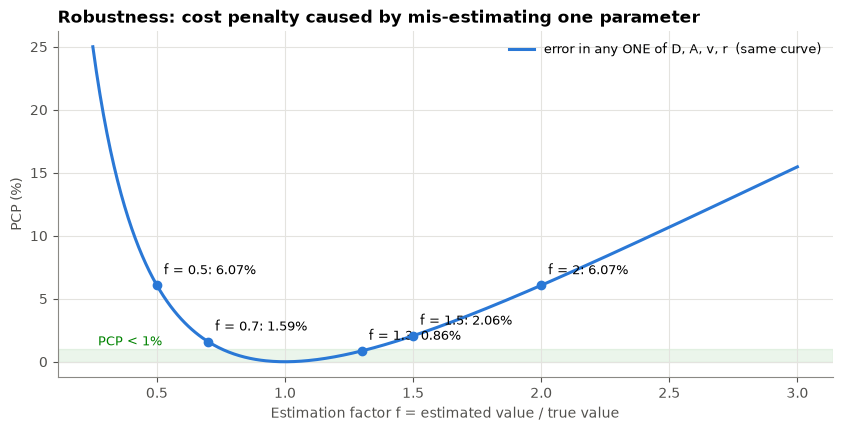

In [23]:
f = np.linspace(0.25, 3, 400)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(f, pcp(np.sqrt(f) - 1), color=C_ORDER, label="error in any ONE of D, A, v, r  (same curve)")
ax.axhspan(0, 1, color=C_OPT, alpha=0.08); ax.text(0.27, 1.3, "PCP < 1%", color=C_OPT, fontsize=9)
for f0 in (0.5, 0.7, 1.3, 1.5, 2):
    ax.scatter([f0], [pcp(np.sqrt(f0) - 1)], color=C_ORDER, zorder=5)
    ax.annotate(f"f = {f0}: {float(pcp(np.sqrt(f0)-1)):.2f}%", (f0, pcp(np.sqrt(f0) - 1)), xytext=(5, 8),
                textcoords="offset points", fontsize=9)
ax.set_xlabel("Estimation factor f = estimated value / true value"); ax.set_ylabel("PCP (%)")
ax.set_title("Robustness: cost penalty caused by mis-estimating one parameter"); ax.legend()
plt.show()

### 🎛️ Interactive demo 4: sensitivity explorer (with PDF export)
Choose a deviation α, **or** a mis-estimation factor for one parameter. The chart shows where $Q'$ sits on the TRC curve and on the PCP curve.

In [24]:
def sensitivity_figure(alpha=0.3, mode="Deviation alpha", factor=1.5, param="D"):
    Qs = eoq(A, D, v, r)
    if mode == "Deviation alpha":
        a = alpha; label = f"alpha = {alpha:+.0%}"
    else:
        est = dict(A=A, D=D, v=v, r=r); est[param] *= factor
        a = eoq(**est) / Qs - 1; label = f"{param} estimated x{factor:g}  ->  alpha = {a:+.1%}"
    Qp = (1 + a) * Qs
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    Q = np.linspace(40, 1200, 600)
    axes[0].plot(Q, trc(Q, A, D, v, r), color=C_TOTAL, label="TRC(Q)")
    axes[0].scatter([Qs], [trc(Qs, A, D, v, r)], color=C_OPT, s=70, zorder=5, label=f"EOQ = {Qs:.0f}")
    axes[0].scatter([Qp], [trc(Qp, A, D, v, r)], color=C_BAD, marker="X", s=90, zorder=5, label=f"Q' = {Qp:.0f}")
    axes[0].fill_between([min(Qs, Qp), max(Qs, Qp)], trc(Qs, A, D, v, r), trc(Qp, A, D, v, r), color=C_BAD, alpha=0.12)
    axes[0].set_ylim(30, 90); axes[0].set_xlabel("Q"); axes[0].set_ylabel("$/yr"); axes[0].legend()
    axes[0].set_title(label)
    al_ = np.linspace(-0.6, 1.2, 400)
    axes[1].plot(al_ * 100, pcp(al_), color=C_TOTAL)
    axes[1].scatter([a * 100], [pcp(a)], color=C_BAD, s=80, zorder=5)
    axes[1].set_title(f"PCP = 50 a^2/(1+a) = {float(pcp(a)):.3f}%   (extra ${trc(Qp,A,D,v,r)-trc(Qs,A,D,v,r):.2f}/yr)")
    axes[1].set_xlabel("alpha (%)"); axes[1].set_ylabel("PCP (%)"); axes[1].set_ylim(0, 40)
    plt.tight_layout()
    return fig

def export_sensitivity_report(name="Sensitivity_Analysis_Report"):
    rep = PDFReport(os.path.join(REPORT_DIR, f"{name}.pdf"), "EOQ Sensitivity Analysis",
                    f"Lecture item: A=${A}, D={D:,.0f}, v=${v}, r={r}")
    rep.text("Percentage cost penalty", [
        r"$Q'=(1+\alpha)EOQ$", r"$PCP=\frac{TRC(Q')-TRC(EOQ)}{TRC(EOQ)}\times 100 = 50\,\frac{\alpha^2}{1+\alpha}$",
        "The PCP depends only on alpha: it is the same for every item. The curve is flat near alpha = 0 and "
        "asymmetric: ordering too little costs more than ordering too much by the same percentage.",
        "A parameter estimated as f times its true value gives 1+alpha = sqrt(f) (for D or A) or 1/sqrt(f) (for v or r)."])
    rep.table(pcp_table.assign(**{"PCP (%)": pcp_table["PCP (%)"].round(3)}), "PCP for selected deviations")
    rep.table(sc[["scenario", "Q_used", "alpha", "PCP (%)", "Extra cost ($/yr)"]].round(3), "Practical policies", landscape=True)
    for a0 in (-0.3, 0.5):
        rep.figure(sensitivity_figure(alpha=a0))
    rep.figure(sensitivity_figure(mode="Parameter error", factor=2, param="D"))
    return rep.close()

if HAS_WIDGETS:
    sa = w.FloatSlider(value=0.3, min=-0.6, max=1.2, step=0.05, description="alpha", continuous_update=False)
    mode = w.ToggleButtons(options=["Deviation alpha", "Parameter error"], description="Mode")
    fac = w.FloatSlider(value=1.5, min=0.25, max=3, step=0.05, description="factor f", continuous_update=False)
    par = w.Dropdown(options=["D", "A", "v", "r"], value="D", description="parameter")
    out4 = w.interactive_output(lambda **k: (sensitivity_figure(**k), plt.show()), dict(alpha=sa, mode=mode, factor=fac, param=par))
    b4 = w.Button(description="📄 Export PDF", button_style="primary"); m4 = w.Output()
    def _e4(_):
        with m4: m4.clear_output(); export_sensitivity_report()
    b4.on_click(_e4)
    display(w.VBox([mode, w.HBox([sa, fac, par, b4]), out4, m4]))
else:
    sensitivity_figure(); plt.show()

In [25]:
# 📄 Export the sensitivity analysis report
export_sensitivity_report()

PDF report saved: c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\reports\Sensitivity_Analysis_Report.pdf  (7 pages)


'c:\\Users\\islam\\Documents\\GitHub\\IME452_InventoryManagementAndControl_FALL2026\\Lecture02\\reports\\Sensitivity_Analysis_Report.pdf'

<a id="s10"></a>
## 10. Economic Production Quantity (EPQ)  📘📊 (slides 18–19)

Now **assumption 8 is relaxed**: the order is not received all at once but is **replenished at a finite rate $m$** units per unit time, as when the item is produced on our own line. We need $m > D$.

* **During production** (length $Q/m$) inventory rises at rate $m-D$.
* **After production** (length $Q/D-Q/m$) inventory falls at rate $D$.
* **Maximum inventory** $=(m-D)\,\frac{Q}{m}=Q\left(1-\frac{D}{m}\right)$, so the average inventory is $\frac{Q}{2}\left(1-\frac{D}{m}\right)$.

$$TRC(Q)=\frac{AD}{Q}+\frac{Q(1-D/m)\,v\,r}{2}\qquad\Longrightarrow\qquad\boxed{EPQ=\sqrt{\frac{2AD}{vr(1-D/m)}}=\frac{EOQ}{\sqrt{1-D/m}}}$$

For produced items, $A$ is the **setup cost** of a production run (changeover time, cleaning, first-piece inspection, scrap).

In [26]:
m_ = sp.symbols("m", positive=True)
TRCp = A_ * D_ / Qs_ + Qs_ * (1 - D_ / m_) * v_ * r_ / 2
EPQ_ = sp.solve(sp.Eq(sp.diff(TRCp, Qs_), 0), Qs_)[0]
display(Markdown("**EPQ from dTRC/dQ = 0:**"), sp.Eq(sp.Symbol("EPQ"), sp.simplify(EPQ_)))
display(Markdown("**Ratio EPQ / EOQ:**"), sp.simplify(EPQ_ / EOQ_))
display(Markdown("**TRC at the EPQ:**"), sp.simplify(TRCp.subs(Qs_, EPQ_)))

**EPQ from dTRC/dQ = 0:**

Eq(EPQ, -sqrt(2)*sqrt(A)*sqrt(D)*sqrt(m)*sqrt(-1/(D - m))/(sqrt(r)*sqrt(v)))

**Ratio EPQ / EOQ:**

-sqrt(m)*sqrt(-1/(D - m))

**TRC at the EPQ:**

-sqrt(2)*sqrt(A)*sqrt(D)*sqrt(r)*sqrt(v)/(sqrt(m)*sqrt(-1/(D - m)))

### 🧮 Worked example 2 (`data/ex2_epq_production.csv`)
A pump housing is machined on a line that produces 48,000 units/year; demand is 12,000 units/year. Setup costs \$450, the unit cost is \$18.50 and r = 0.22.

In [27]:
ex2 = pd.read_csv(os.path.join(DATA_DIR, "ex2_epq_production.csv")); display(ex2)
P2 = dict(zip(ex2["symbol"], ex2["value"]))
A2, D2, v2, r2, m2 = P2["A"], P2["D"], P2["v"], P2["r"], P2["m"]
sol2 = solve_epq(A2, D2, v2, r2, m2)
show_dict(sol2, "Worked example 2: EPQ solution")

,parameter,symbol,value,unit,description
0,annual_demand,D,12000.00,units/year,Demand rate of the finished item
1,setup_cost,A,450.00,$/setup,Fixed cost of one production run (machine setu...
2,unit_cost,v,18.50,$/unit,Unit variable (production) cost of the item
3,carrying_rate,r,0.22,$/$/year,Annual carrying charge
4,production_rate,m,48000.00,units/year,Rate at which the line produces the item while...


**Worked example 2: EPQ solution**

Quantity,Value
EPQ (units),"1,880.9794"
EOQ for comparison (units),"1,628.9760"
EPQ / EOQ = 1/sqrt(1-D/m),1.1547
TRC(EPQ) ($/yr),"5,741.6896"
Setup cost AD/Q ($/yr),"2,870.8448"
Carrying cost ($/yr),"2,870.8448"
Maximum inventory Q(1-D/m) (units),"1,410.7346"
Average inventory (units),705.3673
Production runs per year D/Q,6.3797
Cycle length Q/D (weeks),8.1509


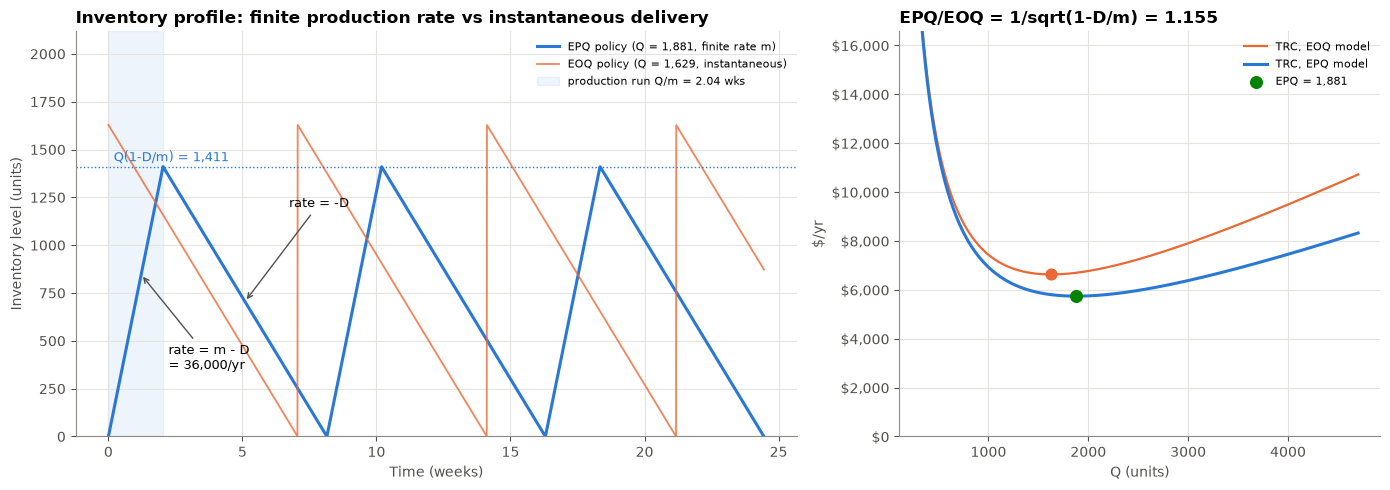

In [28]:
def epq_figure(A, D, v, r, m, horizon_cycles=3):
    Qp, Qe = epq(A, D, v, r, m), eoq(A, D, v, r)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw=dict(width_ratios=[1.5, 1]))
    ax = axes[0]
    H = horizon_cycles * Qp / D
    t, I = inventory_profile(Qp, D, H, m=m)
    ax.plot(t * 52, I, color=C_ORDER, label=f"EPQ policy (Q = {Qp:,.0f}, finite rate m)")
    t2, I2 = inventory_profile(Qe, D, H)
    ax.plot(t2 * 52, I2, color=C_CARRY, lw=1.3, alpha=0.8, label=f"EOQ policy (Q = {Qe:,.0f}, instantaneous)")
    Imax = Qp * (1 - D / m)
    ax.axhline(Imax, color=C_ORDER, ls=":", lw=1); ax.text(0.2, Imax * 1.02, f"Q(1-D/m) = {Imax:,.0f}", color=C_ORDER, fontsize=9)
    tp = Qp / m
    ax.axvspan(0, tp * 52, color=C_ORDER, alpha=0.08, label=f"production run Q/m = {tp*52:.2f} wks")
    ax.annotate(f"rate = m - D\n= {m-D:,.0f}/yr", xy=(tp * 52 * 0.6, (m - D) * tp * 0.6), xytext=(tp * 52 * 1.1, Imax * 0.25),
                arrowprops=dict(arrowstyle="->", color=C_INK2), fontsize=9)
    ax.annotate(f"rate = -D", xy=(tp * 52 + (Qp / D - tp) * 26, Imax / 2), xytext=(tp * 52 + (Qp / D - tp) * 40, Imax * 0.85),
                arrowprops=dict(arrowstyle="->", color=C_INK2), fontsize=9)
    ax.set_xlabel("Time (weeks)"); ax.set_ylabel("Inventory level (units)")
    ax.set_title("Inventory profile: finite production rate vs instantaneous delivery"); ax.legend(loc="upper right", fontsize=8)
    ax.set_ylim(0, max(Qe, Imax) * 1.3)
    ax = axes[1]
    Q = np.linspace(Qe * 0.2, Qp * 2.5, 600)
    ax.plot(Q, trc(Q, A, D, v, r), color=C_CARRY, lw=1.6, label="TRC, EOQ model")
    ax.plot(Q, trc_epq(Q, A, D, v, r, m), color=C_ORDER, label="TRC, EPQ model")
    ax.scatter([Qe], [trc(Qe, A, D, v, r)], color=C_CARRY, s=60, zorder=5)
    ax.scatter([Qp], [trc_epq(Qp, A, D, v, r, m)], color=C_OPT, s=70, zorder=5, label=f"EPQ = {Qp:,.0f}")
    ax.set_ylim(0, trc(Qe, A, D, v, r) * 2.5); ax.yaxis.set_major_formatter(money)
    ax.set_xlabel("Q (units)"); ax.set_ylabel("$/yr"); ax.legend(fontsize=8)
    ax.set_title(f"EPQ/EOQ = 1/sqrt(1-D/m) = {Qp/Qe:.3f}")
    plt.tight_layout()
    return fig

epq_figure(A2, D2, v2, r2, m2); plt.show()

### 📊 How much does the finite production rate matter?
The ratio $EPQ/EOQ = 1/\sqrt{1-D/m}$ depends only on the **utilisation** $D/m$ of the line. When the line is fast compared with demand ($D/m\to0$) the EPQ approaches the EOQ. When the line is almost fully utilised ($D/m\to1$) the EPQ grows without bound: the line runs almost continuously.

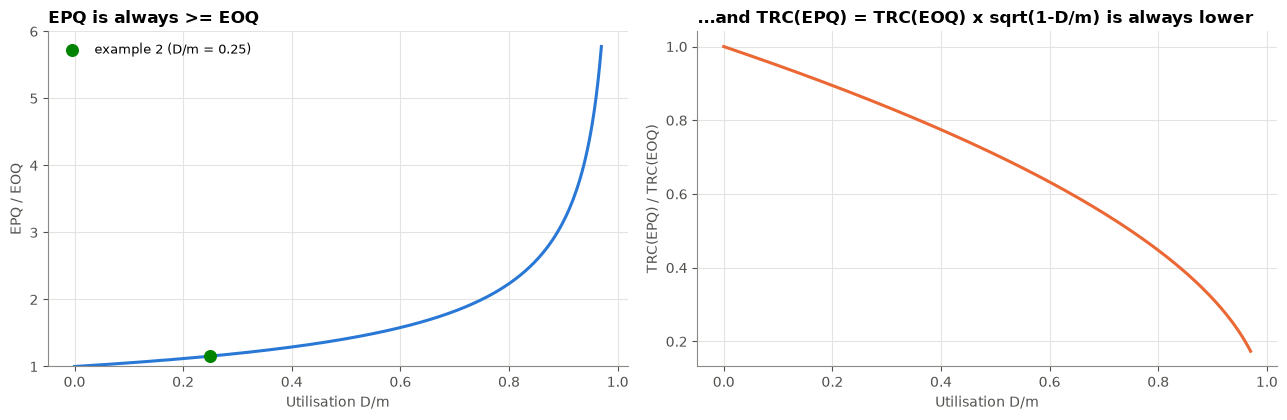

In [29]:
u = np.linspace(0, 0.97, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
axes[0].plot(u, 1 / np.sqrt(1 - u), color=C_ORDER)
axes[0].scatter([D2 / m2], [1 / np.sqrt(1 - D2 / m2)], color=C_OPT, s=70, zorder=5, label=f"example 2 (D/m = {D2/m2:.2f})")
axes[0].set_xlabel("Utilisation D/m"); axes[0].set_ylabel("EPQ / EOQ"); axes[0].set_ylim(1, 6); axes[0].legend()
axes[0].set_title("EPQ is always >= EOQ")
axes[1].plot(u, np.sqrt(1 - u), color=C_CARRY)
axes[1].set_xlabel("Utilisation D/m"); axes[1].set_ylabel("TRC(EPQ) / TRC(EOQ)")
axes[1].set_title("...and TRC(EPQ) = TRC(EOQ) x sqrt(1-D/m) is always lower")
plt.tight_layout(); plt.show()

### 🎛️ Interactive demo 5: EPQ explorer (with PDF export)
Slide **m** down towards **D** and watch the production run lengthen, the peak inventory flatten, and the EPQ move away from the EOQ.

In [30]:
def export_epq_report(A, D, v, r, m, name="EPQ_Report", title="EPQ Solution Report"):
    s = solve_epq(A, D, v, r, m)
    rep = PDFReport(os.path.join(REPORT_DIR, f"{name}.pdf"), title,
                    f"A = ${A:g}, D = {D:,.0f}/yr, v = ${v:g}, r = {r:g}, m = {m:,.0f}/yr")
    rep.text("Model", [
        "Assumption 8 of the EOQ is relaxed: the lot is produced at a finite rate m > D.",
        r"$TRC(Q)=\frac{AD}{Q}+\frac{Q(1-D/m)vr}{2}$",
        r"$EPQ=\sqrt{\frac{2AD}{vr(1-D/m)}}=\frac{EOQ}{\sqrt{1-D/m}}$" + f"$\\ = {s['EPQ (units)']:,.2f}$",
        r"$I_{max}=Q(1-D/m)$" + f"$\\ = {s['Maximum inventory Q(1-D/m) (units)']:,.1f}$",
        "## Interpretation",
        f"Produce {s['EPQ (units)']:,.0f} units per run, {s['Production runs per year D/Q']:.2f} times per year. Each run lasts "
        f"{s['Production run length Q/m (weeks)']:.2f} weeks and the line is then free for {s['Line idle time per cycle (weeks)']:.2f} weeks "
        "for other products."])
    rep.table(s, "Numerical results")
    rep.figure(epq_figure(A, D, v, r, m))
    return rep.close()

def demo_epq(A=450, D=12000, v=18.5, r=0.22, m=48000):
    if m <= D * 1.01:
        print("m must be larger than D"); return
    epq_figure(A, D, v, r, m); plt.show()
    s = solve_epq(A, D, v, r, m)
    print(f"EPQ = {s['EPQ (units)']:,.0f} | EOQ = {s['EOQ for comparison (units)']:,.0f} | Imax = {s['Maximum inventory Q(1-D/m) (units)']:,.0f} | "
          f"run = {s['Production run length Q/m (weeks)']:.2f} wks | cycle = {s['Cycle length Q/D (weeks)']:.2f} wks | TRC = ${s['TRC(EPQ) ($/yr)']:,.0f}")

if HAS_WIDGETS:
    e = dict(A=w.FloatSlider(value=450, min=50, max=2000, step=10, description="A setup $", continuous_update=False),
             D=w.IntSlider(value=12000, min=1000, max=40000, step=500, description="D /yr", continuous_update=False),
             v=w.FloatSlider(value=18.5, min=1, max=100, step=0.5, description="v $", continuous_update=False),
             r=w.FloatSlider(value=0.22, min=0.05, max=0.5, step=0.01, description="r", continuous_update=False),
             m=w.IntSlider(value=48000, min=2000, max=200000, step=1000, description="m /yr", continuous_update=False))
    out5 = w.interactive_output(demo_epq, e)
    b5 = w.Button(description="📄 Export PDF", button_style="primary"); m5 = w.Output()
    def _e5(_):
        with m5:
            m5.clear_output()
            if e["m"].value > e["D"].value:
                export_epq_report(**{k: s.value for k, s in e.items()}, name="EPQ_scenario_from_widget")
    b5.on_click(_e5)
    display(w.VBox([w.HBox([w.VBox([e["A"], e["D"]]), w.VBox([e["v"], e["r"]]), w.VBox([e["m"], b5])]), out5, m5]))
else:
    demo_epq()

In [31]:
# 📄 Export worked example 2
export_epq_report(A2, D2, v2, r2, m2, name="Example2_EPQ_Report", title="Worked Example 2: Economic Production Quantity")

PDF report saved: c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\reports\Example2_EPQ_Report.pdf  (4 pages)


'c:\\Users\\islam\\Documents\\GitHub\\IME452_InventoryManagementAndControl_FALL2026\\Lecture02\\reports\\Example2_EPQ_Report.pdf'

<a id="s11"></a>
## 11. Quantity discounts (all-units)  📘📊 (slides 20–29)

Now **assumption 3 is relaxed**: the unit variable cost depends on the quantity ordered. There are several discount structures; we consider the **all-units discount**: if the order is at least $Q_1$, the discount applies to **every unit** in the order:
$$v=\begin{cases}v_0 & 0\le Q<Q_1\\ v_0(1-d) & Q_1\le Q\end{cases}$$

The acquisition cost $Dv$ now depends on Q, so it **must stay in TRC**:
$$TRC(Q)=\begin{cases}A\frac{D}{Q}+\frac{Q}{2}v_0r+Dv_0 & 0\le Q<Q_1\\[4pt] A\frac{D}{Q}+\frac{Q}{2}v_0(1-d)r+Dv_0(1-d) & Q_1\le Q\end{cases}$$

For $Q\ge Q_1$, TRC takes its lowest values: if $EOQ(d)\ge Q_1$, then $EOQ(d)$ is the optimal quantity. If $EOQ(d)<Q_1$, the decision is a trade-off between **carrying extra inventory** and **a lower acquisition cost**.

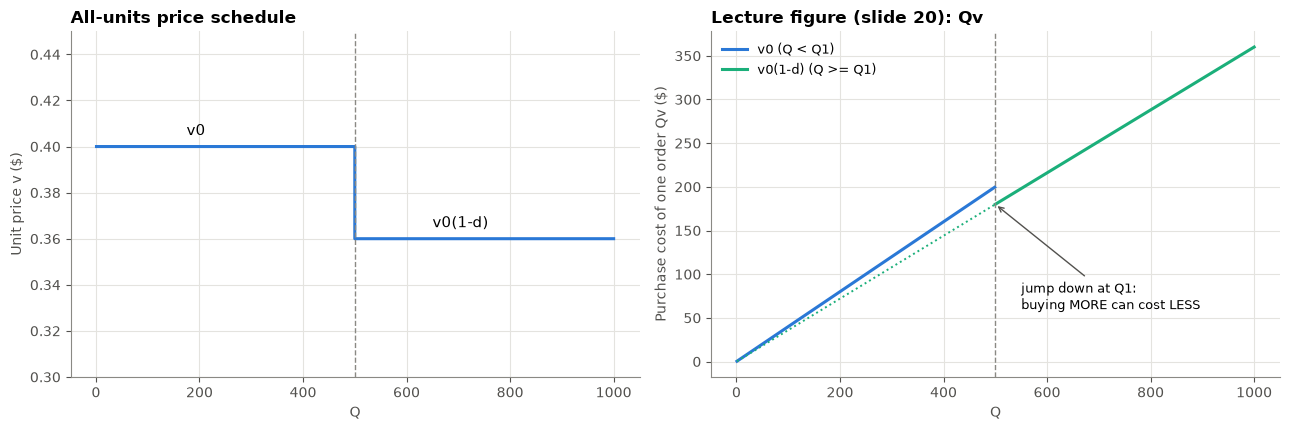

In [32]:
# Slide 20: purchase cost Qv of one order jumps DOWN at Q1 (all-units)
v0_, d_, Q1_ = 0.40, 0.10, 500
Qg = np.linspace(1, 1000, 1000)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
ax = axes[0]
ax.plot(Qg, unit_price(Qg, v0_, d_, Q1_), color=C_ORDER, drawstyle="steps-post")
ax.set_ylim(0.3, 0.45); ax.axvline(Q1_, color=C_MUTED, ls="--", lw=1)
ax.set_xlabel("Q"); ax.set_ylabel("Unit price v ($)"); ax.set_title("All-units price schedule")
ax.text(Q1_ * 0.35, v0_ + 0.005, "v0", fontsize=11); ax.text(Q1_ * 1.3, v0_ * (1 - d_) + 0.005, "v0(1-d)", fontsize=11)
ax = axes[1]
ax.plot(Qg[Qg < Q1_], Qg[Qg < Q1_] * v0_, color=C_ORDER, label="v0 (Q < Q1)")
ax.plot(Qg[Qg >= Q1_], Qg[Qg >= Q1_] * v0_ * (1 - d_), color=C_DISC, label="v0(1-d) (Q >= Q1)")
ax.plot(Qg[Qg < Q1_], Qg[Qg < Q1_] * v0_ * (1 - d_), color=C_DISC, ls=":", lw=1.4)
ax.axvline(Q1_, color=C_MUTED, ls="--", lw=1)
ax.annotate("jump down at Q1:\nbuying MORE can cost LESS", xy=(Q1_, Q1_ * v0_ * (1 - d_)), xytext=(Q1_ * 1.1, 60),
            arrowprops=dict(arrowstyle="->", color=C_INK2), fontsize=9)
ax.set_xlabel("Q"); ax.set_ylabel("Purchase cost of one order Qv ($)"); ax.set_title("Lecture figure (slide 20): Qv"); ax.legend()
plt.tight_layout(); plt.show()

### The three possible cases (slides 22–27)
The three cases below come from `data/ex3_quantity_discount_cases.csv`. They use the lecture item (EOQ = 400 without discount) and three different discount offers.
**Solid segments** are the applicable cost; **dotted segments** are extensions of each curve outside its valid range, drawn the same way as in the lecture figures.

,case_name,D,A,r,v0,d,Q1,note
0,Case 1 - break quantity is optimal,2400,3.2,0.24,0.4,0.02,500,EOQ(d) < Q1 and TRC(Q1) < TRC(EOQ no discount)
1,Case 2 - ignore the discount,2400,3.2,0.24,0.4,0.01,1200,EOQ(d) < Q1 and TRC(Q1) > TRC(EOQ no discount)
2,Case 3 - discounted EOQ is optimal,2400,3.2,0.24,0.4,0.02,300,EOQ(d) >= Q1


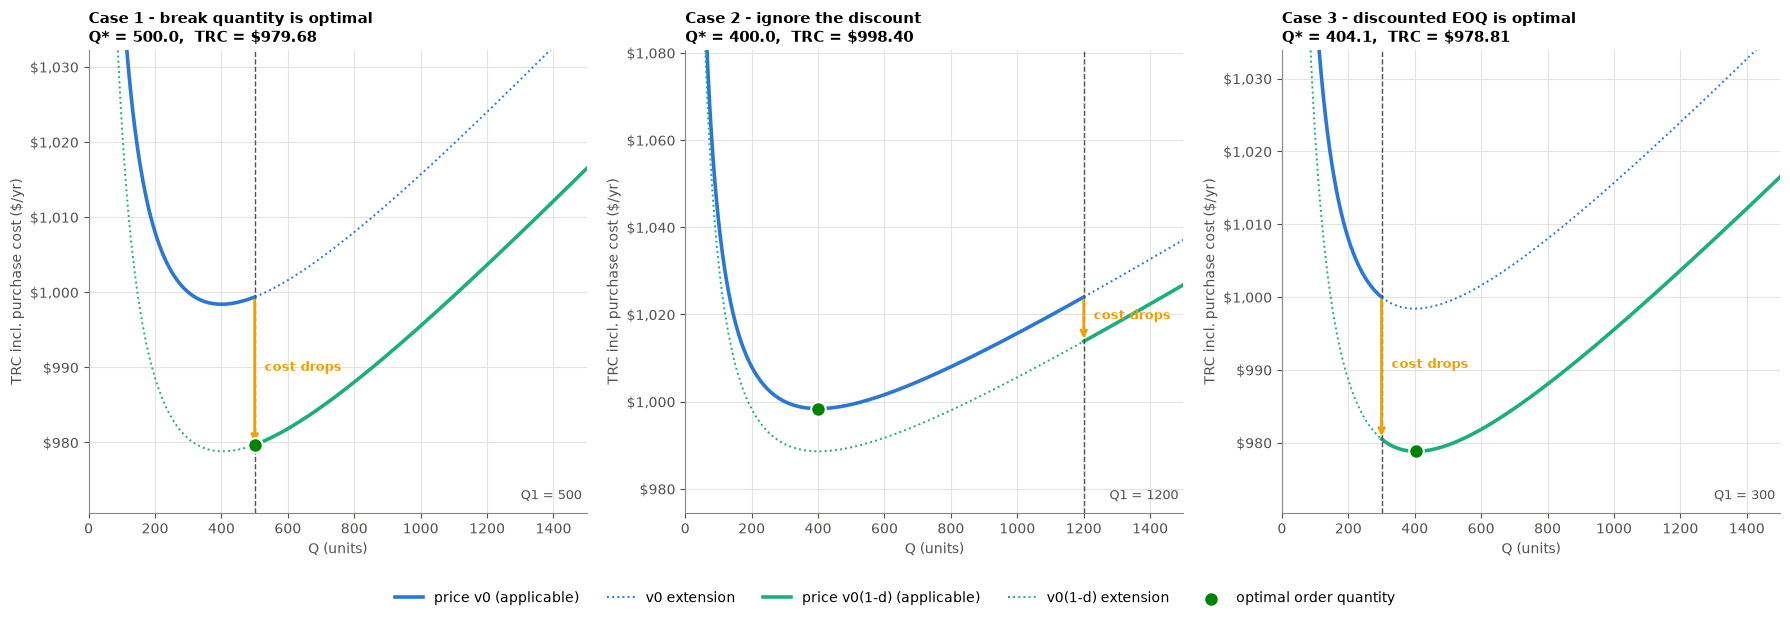

case_name,Q1,d,EOQ_d,EOQ_0,TRC_EOQ0,TRC_Q1,case,Q_opt,TRC_opt,saving_vs_no_discount
Case 1 - break quantity is optimal,500,2%,404.06,400.00,998.40,979.68,1,500.00,979.68,18.72
Case 2 - ignore the discount,1200,1%,402.02,400.00,998.40,"1,013.82",2,400.00,998.40,0.00
Case 3 - discounted EOQ is optimal,300,2%,404.06,400.00,998.40,980.51,3,404.06,978.81,19.59


In [33]:
cases = pd.read_csv(os.path.join(DATA_DIR, "ex3_quantity_discount_cases.csv"))
display(cases)

def discount_figure(A, D, r, v0, d, Q1, ax=None, title=None, Q_max=None, show_steps=False):
    res = solve_all_units(A, D, r, v0, d, Q1, verbose=show_steps)
    Q_max = Q_max or max(2.2 * Q1, 2.2 * res["EOQ_0"])
    Q = np.linspace(Q_max / 30, Q_max, 1500)
    c0 = A * D / Q + Q / 2 * v0 * r + D * v0
    c1 = A * D / Q + Q / 2 * v0 * (1 - d) * r + D * v0 * (1 - d)
    ax = ax or plt.subplots(figsize=(10, 5.2))[1]
    ax.plot(Q[Q < Q1], c0[Q < Q1], color=C_ORDER, lw=2.6, label=f"price v0 = {v0:g} (applicable)")
    ax.plot(Q[Q >= Q1], c0[Q >= Q1], color=C_ORDER, lw=1.4, ls=":", label="v0 extension")
    ax.plot(Q[Q >= Q1], c1[Q >= Q1], color=C_DISC, lw=2.6, label=f"price v0(1-d) = {v0*(1-d):g} (applicable)")
    ax.plot(Q[Q < Q1], c1[Q < Q1], color=C_DISC, lw=1.4, ls=":", label="v0(1-d) extension")
    ax.axvline(Q1, color=C_INK2, ls="--", lw=1)
    top = A * D / Q1 + Q1 / 2 * v0 * r + D * v0
    ax.annotate("", xy=(Q1, res["TRC_Q1"]), xytext=(Q1, top), arrowprops=dict(arrowstyle="->", color=C_YEL, lw=2))
    ax.text(Q1, (top + res["TRC_Q1"]) / 2, "  cost drops", color=C_YEL, fontsize=9, weight="bold")
    ax.scatter([res["Q_opt"]], [res["TRC_opt"]], s=110, color=C_OPT, zorder=6, edgecolor="white", lw=1.5,
               label=f"Q_opt = {res['Q_opt']:,.1f}  (TRC = ${res['TRC_opt']:,.2f})")
    ymin = min(c1.min(), res["TRC_opt"]); span = max(c0[Q > res["EOQ_0"] * 0.5].min(), top) - ymin
    ax.set_ylim(ymin - 0.4 * span, ymin + 2.6 * span); ax.set_xlim(0, Q_max)
    ax.set_xlabel("Q (units)"); ax.set_ylabel("TRC incl. purchase cost ($/yr)")
    ax.yaxis.set_major_formatter(money)
    ax.set_title(title or f"Case {res['case']}:  Q1 = {Q1:g},  d = {d:.0%}")
    ax.text(0.99, 0.03, f"Q1 = {Q1:g}", transform=ax.transAxes, ha="right", fontsize=9, color=C_INK2)
    ax.legend(fontsize=8, loc="upper right")
    return res, ax

fig, axes = plt.subplots(1, 3, figsize=(18, 6.2))
case_results = []
for ax, (_, c) in zip(axes, cases.iterrows()):
    res, _ = discount_figure(c.A, c.D, c.r, c.v0, c.d, c.Q1, ax=ax, title=c.case_name, Q_max=1500)
    case_results.append(dict(case_name=c.case_name, Q1=c.Q1, d=c.d, EOQ_d=res["EOQ_d"], EOQ_0=res["EOQ_0"],
                             TRC_EOQ0=res["TRC_EOQ0"], TRC_Q1=res["TRC_Q1"], case=res["case"],
                             Q_opt=res["Q_opt"], TRC_opt=res["TRC_opt"],
                             saving_vs_no_discount=res["annual_saving_vs_no_discount"]))
    ax.get_legend().remove()
    ax.set_title(f"{c.case_name}\nQ* = {res['Q_opt']:,.1f},  TRC = ${res['TRC_opt']:,.2f}", fontsize=11)
h, l = axes[0].get_legend_handles_labels()
fig.legend(h[:4] + [h[4]], ["price v0 (applicable)", "v0 extension", "price v0(1-d) (applicable)", "v0(1-d) extension",
           "optimal order quantity"], loc="lower center", ncol=5, fontsize=10)
plt.tight_layout(rect=(0, 0.07, 1, 1)); plt.show()
case_df = pd.DataFrame(case_results)
display(case_df.style.format({c: "{:,.2f}" for c in ["EOQ_d", "EOQ_0", "TRC_EOQ0", "TRC_Q1", "Q_opt", "TRC_opt", "saving_vs_no_discount"]} | {"d": "{:.0%}"}).hide(axis="index"))

### The procedure for computing the best order quantity (slides 28–29)
* **Step 1:** compute $EOQ_{discount}=\sqrt{\dfrac{2AD}{v_0(1-d)r}}$
* **Step 2:** if $EOQ(d)\ge Q_1$, then $EOQ(d)$ is the best order quantity (**Case 3**). If $EOQ(d)<Q_1$, go to step 3.
* **Step 3:** compute $TRC(EOQ)=\sqrt{2ADv_0r}+Dv_0$ with $EOQ_{nodiscount}=\sqrt{2AD/(v_0r)}$, and $TRC(Q_1)$.
  * If $TRC(EOQ)<TRC(Q_1)$ → order $EOQ_{nodiscount}$ (**Case 2**).
  * If $TRC(EOQ)>TRC(Q_1)$ → order $Q_1$ (**Case 1**).

`solve_all_units` prints this trace for each case:

In [34]:
for _, c in cases.iterrows():
    display(Markdown(f"#### {c.case_name}"))
    solve_all_units(c.A, c.D, c.r, c.v0, c.d, c.Q1)

#### Case 1 - break quantity is optimal

Step 1: EOQ at the discounted price v0(1-d) = 0.3920:  EOQ(d) = sqrt(2AD/(v0(1-d)r)) = 404.06
Step 2: EOQ(d) = 404.06 < Q1 = 500  ->  go to step 3.
Step 3: EOQ without discount = sqrt(2AD/(v0 r)) = 400.00
        TRC(EOQ) = sqrt(2AD v0 r) + D v0 = 998.40
        TRC(Q1)  = AD/Q1 + Q1 v0(1-d) r/2 + D v0(1-d) = 979.68
        TRC(EOQ) > TRC(Q1)  ->  take the discount, order exactly Q1 (CASE 1).

==> Optimal order quantity Q* = 500.00  (Case 1),  total annual cost = $979.68


#### Case 2 - ignore the discount

Step 1: EOQ at the discounted price v0(1-d) = 0.3960:  EOQ(d) = sqrt(2AD/(v0(1-d)r)) = 402.02
Step 2: EOQ(d) = 402.02 < Q1 = 1,200  ->  go to step 3.
Step 3: EOQ without discount = sqrt(2AD/(v0 r)) = 400.00
        TRC(EOQ) = sqrt(2AD v0 r) + D v0 = 998.40
        TRC(Q1)  = AD/Q1 + Q1 v0(1-d) r/2 + D v0(1-d) = 1,013.82
        TRC(EOQ) < TRC(Q1)  ->  ignore the discount, order EOQ (CASE 2).

==> Optimal order quantity Q* = 400.00  (Case 2),  total annual cost = $998.40


#### Case 3 - discounted EOQ is optimal

Step 1: EOQ at the discounted price v0(1-d) = 0.3920:  EOQ(d) = sqrt(2AD/(v0(1-d)r)) = 404.06
Step 2: EOQ(d) = 404.06 >= Q1 = 300  ->  EOQ(d) is feasible and optimal (CASE 3). Stop.

==> Optimal order quantity Q* = 404.06  (Case 3),  total annual cost = $978.81


> ⚠️ **Edge case not drawn in the slides:** if $EOQ(d)<Q_1\le EOQ_{nodiscount}$, the no-discount EOQ is not feasible (it lies in the discount region). The no-discount curve is still falling at $Q_1$, so the answer is $Q_1$ (Case 1). `solve_all_units` handles this automatically.

### 📊 Discount decision map: which case applies to *any* offer $(d, Q_1)$?
For the lecture item, every combination of discount $d$ and break quantity $Q_1$ is classified below. The black curve is the **break-even discount**: the smallest $d$ that makes ordering $Q_1$ worthwhile. In procurement this curve answers the question *"What is the minimum discount we should negotiate before accepting a larger lot?"*

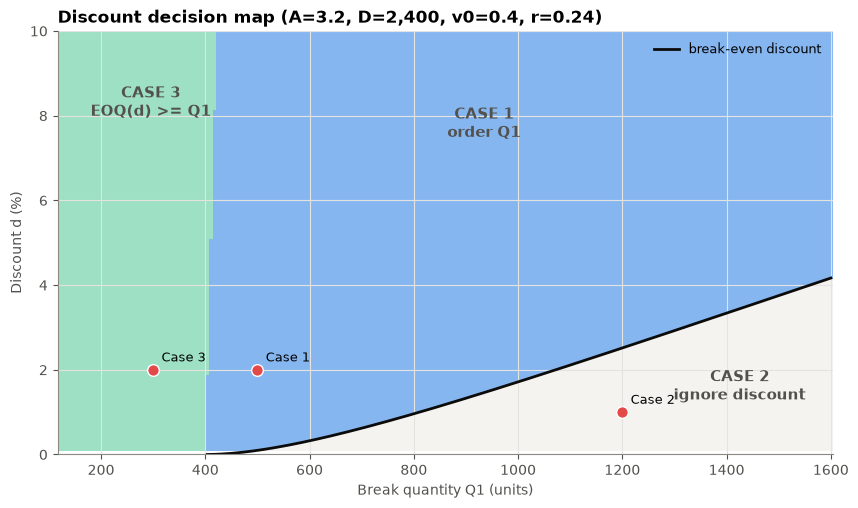

In [35]:
def discount_map(A, D, r, v0, d_max=0.10, Q1_max=None, ax=None):
    Q1_max = Q1_max or 4 * eoq(A, D, v0, r)
    dg = np.linspace(0.001, d_max, 220); qg = np.linspace(eoq(A, D, v0, r) * 0.3, Q1_max, 220)
    Z = np.zeros((len(dg), len(qg)))
    for i, dd in enumerate(dg):
        for j, qq in enumerate(qg):
            Z[i, j] = solve_all_units(A, D, r, v0, dd, qq, verbose=False)["case"]
    ax = ax or plt.subplots(figsize=(10, 5.5))[1]
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(["#86b6ef", "#f4f3ef", "#9ee0c4"])       # case 1 blue, case 2 neutral, case 3 aqua
    ax.pcolormesh(qg, dg * 100, Z, cmap=cmap, vmin=0.5, vmax=3.5, shading="auto")
    # break-even discount: TRC(Q1) = TRC(EOQ0)  (for Q1 > EOQ0)
    q_be = qg[qg > eoq(A, D, v0, r)]
    T0 = np.sqrt(2 * A * D * v0 * r) + D * v0
    d_be = 1 - (T0 - A * D / q_be) / (v0 * (q_be * r / 2 + D))
    ax.plot(q_be, d_be * 100, color=C_INK, lw=2, label="break-even discount")
    for lab, (x, y) in {"CASE 3\nEOQ(d) >= Q1": (0.12, 0.8), "CASE 1\norder Q1": (0.55, 0.75), "CASE 2\nignore discount": (0.88, 0.13)}.items():
        ax.text(x, y, lab, transform=ax.transAxes, fontsize=11, weight="bold", color=C_INK2, ha="center")
    ax.set_ylim(0, d_max * 100); ax.set_xlabel("Break quantity Q1 (units)"); ax.set_ylabel("Discount d (%)")
    ax.set_title(f"Discount decision map (A={A:g}, D={D:,.0f}, v0={v0:g}, r={r:g})"); ax.legend(loc="upper right")
    return ax

ax = discount_map(3.2, 2400, 0.24, 0.40)
for _, c in cases.iterrows():
    ax.scatter([c.Q1], [c.d * 100], color=C_BAD, s=70, zorder=5, edgecolor="white")
    ax.annotate(c.case_name.split(" -")[0], (c.Q1, c.d * 100), xytext=(6, 6), textcoords="offset points", fontsize=9)
plt.show()

### 🎛️ Interactive demo 6: quantity-discount negotiator (with PDF export)
You are the buyer. The supplier offers **d %** off for orders of at least **Q1**. Change the offer and see which case applies, what the best order quantity is and how much the company saves per year compared with ignoring the offer.

In [36]:
def export_discount_report(A, D, r, v0, offers, name="Quantity_Discount_Report", title="All-Units Quantity Discount Analysis"):
    """offers: list of (d, Q1) tuples or a DataFrame with columns d, Q1 (and optionally case_name)."""
    if isinstance(offers, pd.DataFrame):
        offers = list(offers[["d", "Q1"]].itertuples(index=False, name=None))
    rep = PDFReport(os.path.join(REPORT_DIR, f"{name}.pdf"), title, f"A = ${A:g}, D = {D:,.0f}/yr, v0 = ${v0:g}, r = {r:g}")
    rep.text("Procedure (lecture slides 28-29)", [
        r"$v = v_0\ \ (Q<Q_1);\qquad v=v_0(1-d)\ \ (Q\geq Q_1)$",
        r"$TRC(Q)=A\frac{D}{Q}+\frac{Q}{2}vr+Dv$",
        "## Step 1", r"$EOQ_{discount}=\sqrt{\frac{2AD}{v_0(1-d)r}}$",
        "## Step 2", "If EOQ(d) >= Q1, EOQ(d) is the best order quantity (Case 3); otherwise go to step 3.",
        "## Step 3", r"$TRC(EOQ)=\sqrt{2ADv_0r}+Dv_0\quad$ vs. $\quad TRC(Q_1)$",
        "If TRC(EOQ) < TRC(Q1) order the no-discount EOQ (Case 2); if TRC(EOQ) > TRC(Q1) order Q1 (Case 1)."])
    rows = []
    for d, Q1 in offers:
        res = solve_all_units(A, D, r, v0, d, Q1, verbose=False)
        rows.append({"d": f"{d:.1%}", "Q1": Q1, "EOQ(d)": round(res["EOQ_d"], 2), "EOQ(0)": round(res["EOQ_0"], 2),
                     "TRC(EOQ0)": round(res["TRC_EOQ0"], 2), "TRC(Q1)": round(res["TRC_Q1"], 2), "Case": res["case"],
                     "Q*": round(res["Q_opt"], 2), "Saving $/yr": round(res["annual_saving_vs_no_discount"], 2)})
        rep.text(f"Offer: d = {d:.1%} for Q >= {Q1:g}", ["## Solution trace"] + res["steps"] +
                 [f"RESULT: order Q* = {res['Q_opt']:,.2f} units (Case {res['case']}); annual saving vs ignoring the offer = ${res['annual_saving_vs_no_discount']:,.2f}"])
        fig, ax = plt.subplots(figsize=(11, 5.5)); discount_figure(A, D, r, v0, d, Q1, ax=ax); rep.figure(fig)
    rep.table(pd.DataFrame(rows), "Summary of all offers", fmt="{:,.2f}", landscape=True)
    fig, ax = plt.subplots(figsize=(11, 6)); discount_map(A, D, r, v0, d_max=max(0.1, max(o[0] for o in offers) * 1.3),
                                                          Q1_max=max(4 * eoq(A, D, v0, r), max(o[1] for o in offers) * 1.3), ax=ax)
    for d, Q1 in offers: ax.scatter([Q1], [d * 100], color=C_BAD, s=60, zorder=5)
    rep.figure(fig, "Discount decision map with the analysed offers (red dots).")
    return rep.close()

def demo_discount(A=3.2, D=2400, r=0.24, v0=0.40, d=0.02, Q1=500):
    fig, ax = plt.subplots(figsize=(11, 5.4))
    res, _ = discount_figure(A, D, r, v0, d, Q1, ax=ax)
    plt.show()
    print("\n".join(res["steps"]))
    print(f"\n==> Q* = {res['Q_opt']:,.1f} (Case {res['case']}),  saving vs ignoring the offer = ${res['annual_saving_vs_no_discount']:,.2f}/yr")

if HAS_WIDGETS:
    q = dict(A=w.FloatSlider(value=3.2, min=0.5, max=50, step=0.1, description="A $", continuous_update=False),
             D=w.IntSlider(value=2400, min=100, max=20000, step=100, description="D /yr", continuous_update=False),
             r=w.FloatSlider(value=0.24, min=0.05, max=0.5, step=0.01, description="r", continuous_update=False),
             v0=w.FloatSlider(value=0.40, min=0.05, max=10, step=0.05, description="v0 $", continuous_update=False),
             d=w.FloatSlider(value=0.02, min=0.0, max=0.2, step=0.0025, readout_format=".2%", description="discount d", continuous_update=False),
             Q1=w.IntSlider(value=500, min=10, max=3000, step=10, description="break Q1", continuous_update=False))
    preset = w.Dropdown(options=["(custom)"] + list(cases["case_name"]), description="Load case")
    def _load(change):
        if change["new"] in list(cases["case_name"]):
            c = cases[cases.case_name == change["new"]].iloc[0]
            for k in ("A", "D", "r", "v0", "d", "Q1"): q[k].value = c[k]
    preset.observe(_load, names="value")
    out6 = w.interactive_output(demo_discount, q)
    b6 = w.Button(description="📄 Export PDF", button_style="primary"); m6 = w.Output()
    def _e6(_):
        with m6:
            m6.clear_output()
            export_discount_report(q["A"].value, q["D"].value, q["r"].value, q["v0"].value, [(q["d"].value, q["Q1"].value)],
                                   name="Discount_scenario_from_widget")
    b6.on_click(_e6)
    display(w.VBox([preset, w.HBox([w.VBox([q["A"], q["D"]]), w.VBox([q["r"], q["v0"]]), w.VBox([q["d"], q["Q1"]]), b6]), out6, m6]))
else:
    demo_discount()

In [37]:
# 📄 Export the three lecture cases in one report
c0 = cases.iloc[0]
export_discount_report(c0.A, c0.D, c0.r, c0.v0, cases, name="Example3_Quantity_Discount_Cases",
                       title="Worked Example 3: Quantity Discounts, Cases 1-3")

PDF report saved: c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\reports\Example3_Quantity_Discount_Cases.pdf  (10 pages)


'c:\\Users\\islam\\Documents\\GitHub\\IME452_InventoryManagementAndControl_FALL2026\\Lecture02\\reports\\Example3_Quantity_Discount_Cases.pdf'

<a id="s12"></a>
## 12. Practice problems with an automatic checker  ✍️

The problems are in `data/practice_problems.csv` (instructors can add rows to create new problems). Solve each problem **by hand first**, then check your answers:
* with the **quiz widget** below, or
* in code: `check("P1", EOQ=407.9, orders_per_year=12.75, TRC=1019.8)`.

Answers are accepted within **±1 %**. `show_solution("P1")` shows the full solution.

In [38]:
practice = pd.read_csv(os.path.join(DATA_DIR, "practice_problems.csv"))
display(practice[["problem_id", "model", "question"]].style.hide(axis="index").set_properties(**{"text-align": "left"}))

def answer_key(pid):
    p = practice.set_index("problem_id").loc[pid]
    if p.model == "EOQ":
        s = solve_eoq(p.A, p.D, p.v, p.r)
        return {"EOQ": s["EOQ (units)"], "orders_per_year": s["Orders per year D/Q"], "TRC": s["TRC(EOQ) ($/yr)"],
                "T_months": s["T_EOQ (months of supply)"], "TR": s["Turnover ratio TR = D/I_bar"]}
    if p.model == "PCP":
        Qs = eoq(p.A, p.D, p.v, p.r); a = p.Q_used / Qs - 1
        return {"EOQ": Qs, "alpha": a, "PCP": float(pcp(a))}
    if p.model == "EPQ":
        s = solve_epq(p.A, p.D, p.v, p.r, p.m)
        return {"EPQ": s["EPQ (units)"], "max_inventory": s["Maximum inventory Q(1-D/m) (units)"],
                "run_weeks": s["Production run length Q/m (weeks)"]}
    if p.model == "DISCOUNT":
        s = solve_all_units(p.A, p.D, p.r, p.v, p.d, p.Q1, verbose=False)
        return {"Q_opt": s["Q_opt"], "case": s["case"]}

def check(pid, tol=0.01, **answers):
    key = answer_key(pid); lines = []
    for k, val in answers.items():
        if k not in key:
            lines.append(f"  ?  '{k}' is not graded for {pid}; graded items: {list(key)}"); continue
        ok = abs(val - key[k]) <= tol * max(abs(key[k]), 1e-9) if k != "case" else int(val) == key[k]
        lines.append(f"  {'✅' if ok else '❌'}  {k} = {val}" + ("" if ok else "   (not correct, try again)"))
    print(f"{pid}:\n" + "\n".join(lines))

def show_solution(pid):
    p = practice.set_index("problem_id").loc[pid]
    display(Markdown(f"**{pid} ({p.model})**: {p.question}"))
    if p.model == "DISCOUNT":
        solve_all_units(p.A, p.D, p.r, p.v, p.d, p.Q1)
    elif p.model == "EPQ":
        show_dict(solve_epq(p.A, p.D, p.v, p.r, p.m))
    elif p.model == "PCP":
        show_dict(solve_eoq(p.A, p.D, p.v, p.r, Q_used=p.Q_used))
    else:
        show_dict(solve_eoq(p.A, p.D, p.v, p.r))

# example of use (P1 with deliberately one wrong answer)
check("P1", EOQ=407.9, orders_per_year=12.75, TRC=950)

problem_id,model,question
P1,EOQ,"Find the EOQ, the number of orders per year and TRC(EOQ)."
P2,EOQ,Express the EOQ as months of supply (T_EOQ) and compute the turnover ratio TR.
P3,PCP,The buyer orders 600 units each time. What is the percentage cost penalty (PCP)?
P4,EPQ,"Compute EPQ, the maximum inventory level and the length of each production run (weeks, 52 weeks/year)."
P5,DISCOUNT,All-units discount of 3% for Q >= 400. Find the best order quantity and which case applies.
P6,DISCOUNT,All-units discount of 1% for Q >= 800. Find the best order quantity and which case applies.
P7,DISCOUNT,All-units discount of 4% for Q >= 200. Find the best order quantity and which case applies.


P1:
  ✅  EOQ = 407.9
  ✅  orders_per_year = 12.75
  ❌  TRC = 950   (not correct, try again)


In [39]:
# 🎛️ Quiz widget
if HAS_WIDGETS:
    pick = w.Dropdown(options=list(practice["problem_id"]), description="Problem")
    qtext = w.HTML(); boxes = w.VBox(); fb = w.Output()
    btn_c = w.Button(description="Check answers", button_style="success")
    btn_s = w.Button(description="Show solution", button_style="warning")
    def _render(*_):
        p = practice.set_index("problem_id").loc[pick.value]
        params = ", ".join(f"{k} = {p[k]:g}" for k in ["D", "A", "v", "r", "m", "d", "Q1", "Q_used"] if not pd.isna(p[k]))
        qtext.value = f"<b>{pick.value}</b>: {p.question}<br><i>Data: {params}</i>"
        boxes.children = [w.FloatText(description=k, layout=w.Layout(width="260px")) for k in answer_key(pick.value)]
        fb.clear_output()
    def _check(_):
        with fb:
            fb.clear_output(); check(pick.value, **{b.description: b.value for b in boxes.children if b.value != 0})
    def _sol(_):
        with fb:
            fb.clear_output(); show_solution(pick.value)
    pick.observe(_render, names="value"); btn_c.on_click(_check); btn_s.on_click(_sol); _render()
    display(w.VBox([pick, qtext, boxes, w.HBox([btn_c, btn_s]), fb]))

<a id="s13"></a>
## 13. Solve your own problem and export a full lecture report  🧮📄

### 13.1 Universal solver
Pick a model, enter the data and press **Solve & export**. The result is shown here and saved as a PDF in `reports/`. This is useful for homework and for checking hand calculations.

In [40]:
def solve_and_export(model, A, D, v, r, m=None, d=None, Q1=None, Q_used=None, name="My_Problem"):
    if model == "EOQ":
        show_dict(solve_eoq(A, D, v, r, Q_used)); eoq_scenario_figure(A, D, v, r, Q_used or eoq(A, D, v, r)); plt.show()
        return export_eoq_report(A, D, v, r, Q_used, name=name, title="EOQ Solution Report")
    if model == "EPQ":
        show_dict(solve_epq(A, D, v, r, m)); epq_figure(A, D, v, r, m); plt.show()
        return export_epq_report(A, D, v, r, m, name=name)
    if model == "All-units discount":
        demo_discount(A, D, r, v, d, Q1)
        return export_discount_report(A, D, r, v, [(d, Q1)], name=name)

if HAS_WIDGETS:
    u = dict(model=w.ToggleButtons(options=["EOQ", "EPQ", "All-units discount"], description="Model"),
             A=w.FloatText(value=40, description="A ($)"), D=w.FloatText(value=5200, description="D (/yr)"),
             v=w.FloatText(value=12.5, description="v or v0 ($)"), r=w.FloatText(value=0.2, description="r"),
             m=w.FloatText(value=20000, description="m (EPQ)"), d=w.FloatText(value=0.03, description="d (disc.)"),
             Q1=w.FloatText(value=1000, description="Q1 (disc.)"), Q_used=w.FloatText(value=0, description="Q used (EOQ)"),
             name=w.Text(value="My_Problem", description="File name"))
    bu = w.Button(description="Solve & export PDF", button_style="primary"); ou = w.Output()
    def _solve(_):
        with ou:
            ou.clear_output()
            k = {n: s.value for n, s in u.items()}
            k["Q_used"] = k["Q_used"] or None
            solve_and_export(**k)
    bu.on_click(_solve)
    display(w.VBox([u["model"], w.HBox([w.VBox([u["A"], u["D"], u["v"], u["r"]]), w.VBox([u["m"], u["d"], u["Q1"], u["Q_used"]]),
                                        w.VBox([u["name"], bu])]), ou]))

### 13.2 One PDF with the whole lecture
`export_full_lecture_report()` puts every worked example of this notebook (theory pages, solutions and all main charts) into a single PDF. It can be used as a handout.

In [41]:
def export_full_lecture_report(name="Full_Lecture_Report"):
    rep = PDFReport(os.path.join(REPORT_DIR, f"{name}.pdf"), "Order Quantities When Demand is Approximately Level",
                    "EOQ, sensitivity, EPQ and quantity discounts: worked examples", author="Dr. Islam Ali")
    rep.text("1. The EOQ model", [
        "## Assumptions", "1 constant, deterministic demand; 2 Q need not be an integer, no min/max; 3 no quantity discounts; "
        "4 costs constant over time; 5 items independent; 6 zero (or known) lead time; 7 no shortages; 8 whole order delivered at once; "
        "9 very long horizon.",
        "## Costs", r"$C_r=\frac{A+Qv}{Q/D}=\frac{AD}{Q}+vD \qquad C_c=\bar{I}vr=\frac{Qvr}{2}$",
        r"$TRC(Q)=\frac{Qvr}{2}+\frac{AD}{Q}$",
        "## Optimum", r"$\frac{dTRC}{dQ}=\frac{vr}{2}-\frac{AD}{Q^2}=0\ \Rightarrow\ EOQ=\sqrt{\frac{2AD}{vr}},\qquad TRC(EOQ)=\sqrt{2ADvr}$",
        "## Other expressions", r"$T_{EOQ}=\sqrt{\frac{288A}{Dvr}}\ \mathrm{months}\qquad TR=\sqrt{\frac{2vrD}{A}}$",
        "## Sensitivity", r"$Q'=(1+\alpha)EOQ\ \Rightarrow\ PCP=50\frac{\alpha^2}{1+\alpha}$",
        "## EPQ", r"$TRC(Q)=\frac{AD}{Q}+\frac{Q(1-D/m)vr}{2}\qquad EPQ=\frac{EOQ}{\sqrt{1-D/m}}$",
        "## All-units discount", "Step 1: EOQ(d); if EOQ(d) >= Q1 it is optimal (Case 3). Otherwise compare TRC(EOQ no discount) with "
        "TRC(Q1): the smaller one wins (Case 2 or Case 1)."])
    rep.table(solve_eoq(A, D, v, r, Q_used=600), "Worked example 1: EOQ (A=3.2, D=2400, v=0.40, r=0.24, Q used = 600)")
    rep.figure(eoq_scenario_figure(A, D, v, r, 600))
    fig, ax = plt.subplots(figsize=(11, 4.5)); plot_sawtooth(400, 2400, 1.0, ax=ax); ax.set_title("EOQ sawtooth"); rep.figure(fig)
    rep.table(sc[["scenario", "Q_used", "alpha", "PCP (%)", "Extra cost ($/yr)"]].round(3), "Sensitivity: practical policies", landscape=True)
    rep.figure(sensitivity_figure(alpha=0.5))
    rep.table(solve_epq(A2, D2, v2, r2, m2), "Worked example 2: EPQ")
    rep.figure(epq_figure(A2, D2, v2, r2, m2))
    rep.table(case_df.drop(columns=["case_name"]).round(3), "Worked example 3: quantity discount cases", landscape=True)
    for _, c in cases.iterrows():
        fig, ax = plt.subplots(figsize=(11, 5.5)); discount_figure(c.A, c.D, c.r, c.v0, c.d, c.Q1, ax=ax, title=c.case_name, Q_max=1500)
        rep.figure(fig)
    fig, ax = plt.subplots(figsize=(11, 6)); discount_map(3.2, 2400, 0.24, 0.40, ax=ax); rep.figure(fig)
    return rep.close()

export_full_lecture_report()

PDF report saved: c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\reports\Full_Lecture_Report.pdf  (14 pages)


'c:\\Users\\islam\\Documents\\GitHub\\IME452_InventoryManagementAndControl_FALL2026\\Lecture02\\reports\\Full_Lecture_Report.pdf'

<a id="s14"></a>
## 14. 🏭 Industrial tool: the Lot-Sizing Decision Tool

Everything in this lecture is packaged in a **stand-alone tool** that you can take to an internship or a job:

```
industrial_tool/
├── lot_sizing_tool.py                 ← one Python file (command line or import)
├── USER_GUIDE.md                      ← complete manual: data collection, formulas, reading the outputs
├── input/blank_input_template.xlsx    ← template with instructions, drop-down lists and a data dictionary
├── input/example_company_input.xlsx   ← worked example: 23 items of a fictional pump manufacturer
└── output/                            ← Excel results + PDF management report
```

**What it adds beyond the textbook formulas**, as a real company needs:

| Real-world issue | How the tool handles it | Lecture link |
|---|---|---|
| Hundreds of SKUs | Loops over an Excel item list | single-item model applied item by item (slide 3) |
| Purchased vs produced items | EOQ or EPQ chosen per item | slides 13, 19 |
| Supplier price lists with **several** breaks | Generalised all-units procedure: best point of each tier, then compare | slides 20–29 |
| Pack sizes, MOQ, storage limits | Rounds and clips, then re-optimises on total cost | assumption 2 relaxed |
| "When do I order?" | Reorder point = D·L | assumption 6 |
| "Is our current policy bad?" | Savings and PCP of the current Q | slide 17 |
| "Can I round to full pallets?" | **Flexibility band**: range of Q within x % of optimal cost | flat PCP curve |
| Data-entry mistakes | Validation log (errors skip the item, warnings are explained) | – |
| Management communication | Formatted Excel + PDF report with charts | – |

### 14.1 How the tool works

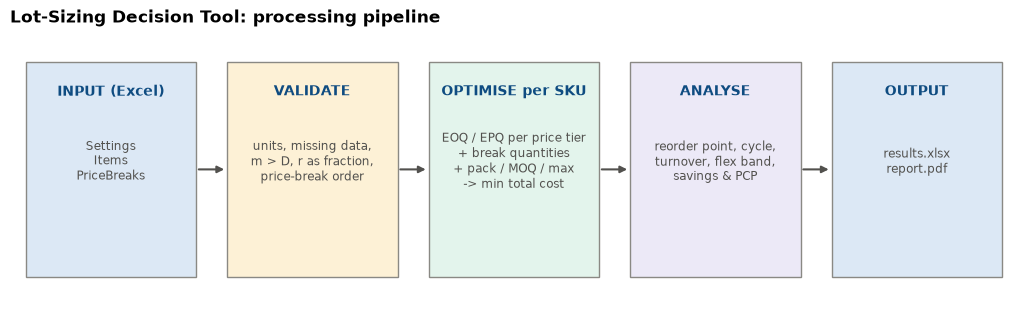

In [42]:
def tool_flow_diagram():
    fig, ax = plt.subplots(figsize=(13, 3.6)); ax.axis("off"); ax.set_xlim(0, 13); ax.set_ylim(0, 3.6)
    boxes = [(0.2, "INPUT (Excel)", "Settings\nItems\nPriceBreaks", "#dce8f5"),
             (2.8, "VALIDATE", "units, missing data,\nm > D, r as fraction,\nprice-break order", "#fdf1d6"),
             (5.4, "OPTIMISE per SKU", "EOQ / EPQ per price tier\n+ break quantities\n+ pack / MOQ / max\n-> min total cost", "#e3f4ec"),
             (8.0, "ANALYSE", "reorder point, cycle,\nturnover, flex band,\nsavings & PCP", "#ece9f7"),
             (10.6, "OUTPUT", "results.xlsx\nreport.pdf", "#dce8f5")]
    for x, title, body, col in boxes:
        ax.add_patch(plt.Rectangle((x, 0.4), 2.2, 2.8, facecolor=col, edgecolor=C_MUTED))
        ax.text(x + 1.1, 2.9, title, ha="center", va="top", weight="bold", fontsize=10, color=C_HEAD)
        ax.text(x + 1.1, 1.9, body, ha="center", va="center", fontsize=8.5, color=C_INK2)
    for x in (2.4, 5.0, 7.6, 10.2):
        ax.annotate("", xy=(x + 0.4, 1.8), xytext=(x, 1.8), arrowprops=dict(arrowstyle="-|>", color=C_INK2, lw=1.5))
    ax.set_title("Lot-Sizing Decision Tool: processing pipeline")
    return fig
tool_flow_diagram(); plt.show()

### 14.2 Running the tool
**From a terminal** (in the `industrial_tool` folder):
```bash
python lot_sizing_tool.py --template input/my_plant_input.xlsx        # create a blank template
python lot_sizing_tool.py --input input/example_company_input.xlsx --outdir output
python lot_sizing_tool.py --input my.xlsx --outdir out --no-pdf        # Excel only (very large lists)
python lot_sizing_tool.py --input my.xlsx --sku-pages 10               # detail pages for the top-10 savings only
```
**From this notebook** (next cell): import the module and call `run()`.

In [43]:
sys.path.insert(0, TOOL_DIR)
import importlib, lot_sizing_tool as lst
importlib.reload(lst)
print(f"Lot-Sizing Tool version {lst.__version__}")

# A look at the input workbook
xin = os.path.join(TOOL_DIR, "input", "example_company_input.xlsx")
display(Markdown("**Settings sheet**")); display(pd.read_excel(xin, sheet_name="Settings"))
display(Markdown("**Items sheet (first 8 rows)**")); display(pd.read_excel(xin, sheet_name="Items").head(8))
display(Markdown("**PriceBreaks sheet**")); display(pd.read_excel(xin, sheet_name="PriceBreaks"))

Lot-Sizing Tool version 1.0.0


**Settings sheet**

,setting,value,description
0,company_name,Delta Pumps & Valves Co. (fictional case),Name printed on the report cover
1,report_title,Lot-Sizing Recommendations - FY2027,Title printed on the report cover
2,analyst,Industrial Engineering Intern,Person who prepared the analysis
3,currency,$,Currency symbol used in outputs
4,days_per_year,250,Working days per year (used to convert lead ti...
5,default_carrying_rate,0.24,Carrying charge r ($/$/year) used when an item...
6,flex_tolerance_pct,2,Cost tolerance (%) that defines the 'flexibili...


**Items sheet (first 8 rows)**

,sku,description,category,supply_type,annual_demand,order_cost,unit_cost,carrying_rate,production_rate,lead_time_days,pack_size,min_order_qty,max_order_qty,current_order_qty
0,RM-1001,Steel bar 25mm (m),Raw material,Purchased,36000,85,4.20,NaN,NaN,10,100,500.0,NaN,6000
1,RM-1002,Cast iron pump housing,Raw material,Purchased,4800,140,38.00,NaN,NaN,20,10,NaN,NaN,400
2,RM-1003,Bronze impeller blank,Raw material,Purchased,5200,120,22.50,NaN,NaN,15,20,NaN,NaN,1300
3,RM-1004,Mechanical seal kit,Purchased part,Purchased,9600,60,11.80,NaN,NaN,12,24,NaN,NaN,800
4,RM-1005,Ball bearing 6204-2RS,Purchased part,Purchased,24000,45,1.35,NaN,NaN,7,50,1000.0,NaN,2000
5,RM-1006,O-ring set NBR,Purchased part,Purchased,60000,35,0.18,NaN,NaN,5,500,NaN,NaN,5000
6,RM-1007,Stainless bolt M10 (box of 1),Purchased part,Purchased,150000,30,0.06,NaN,NaN,5,1000,10000.0,NaN,50000
7,RM-1008,Electric motor 2.2 kW,Purchased part,Purchased,2400,220,165.00,NaN,NaN,30,1,NaN,150.0,100


**PriceBreaks sheet**

,sku,min_qty,unit_cost
0,RM-1001,5000,4.05
1,RM-1001,12000,3.95
2,RM-1002,500,36.50
3,RM-1002,1000,35.20
4,RM-1003,1000,21.60
5,RM-1004,2000,11.00
6,RM-1005,5000,1.30
7,RM-1005,10000,1.24
8,RM-1006,25000,0.17
9,RM-1008,200,158.00


In [44]:
# Run the full pipeline on the example company
result = lst.run(xin, os.path.join(TOOL_DIR, "output"))
res = result["results"]
display(Markdown("**Validation log**: problems the tool found in the input"), result["log"])
cols = ["sku", "model", "textbook_q", "recommended_q", "discount_case", "binding_constraints", "unit_price_paid",
        "orders_per_year", "reorder_point", "annual_relevant_cost", "current_q", "annual_savings", "current_pcp_pct"]
display(res[cols].style.format({"textbook_q": "{:,.1f}", "recommended_q": "{:,.0f}", "unit_price_paid": "{:,.3f}",
        "orders_per_year": "{:,.1f}", "reorder_point": "{:,.0f}", "annual_relevant_cost": "${:,.0f}", "current_q": "{:,.0f}",
        "annual_savings": "${:,.0f}", "current_pcp_pct": "{:.1f}%"}).bar(subset=["annual_savings"], color="#86b6ef").hide(axis="index"))

Lot-Sizing Tool v1.0.0  |  Delta Pumps & Valves Co. (fictional case)
  items analysed        : 22  (validation messages: 2)
  annual savings        : $41,700.05
  avg inventory value   : $309,125 (current) -> $286,172 (recommended, all items)
  Excel results         : c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\industrial_tool\output\example_company_results.xlsx
  PDF report            : c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\industrial_tool\output\example_company_report.pdf


**Validation log**: problems the tool found in the input

,sku,level,message
0,RM-1013,WARNING,carrying_rate 22.0 > 1 - did you enter a perce...
1,FG-3005,ERROR,production_rate (2000) must exceed annual_dema...


sku,model,textbook_q,recommended_q,discount_case,binding_constraints,unit_price_paid,orders_per_year,reorder_point,annual_relevant_cost,current_q,annual_savings,current_pcp_pct
RM-1001,EOQ + discounts,"2,464.0","12,000",Tier 3 of 3 (at break qty),Pack 100,3.950,3.0,"1,440","$5,943","6,000","$1,083",18.2%
RM-1002,EOQ + discounts,383.9,"1,000",Tier 3 of 3 (at break qty),Pack 10,35.200,4.8,384,"$4,896",400,"$12,048",246.1%
RM-1003,EOQ + discounts,480.7,"1,000",Case 1 (order break qty Q1),Pack 20,21.600,5.2,312,"$3,216","1,300",$634,19.7%
RM-1004,EOQ + discounts,637.8,"2,016",Case 1 (order break qty Q1),Pack 24,11.000,4.8,461,"$2,947",800,"$6,586",223.5%
RM-1005,EOQ + discounts,"2,582.0","10,000",Tier 3 of 3 (at break qty),Pack 50,1.240,2.4,672,"$1,596","2,000","$1,908",119.5%
RM-1006,EOQ + discounts,"9,860.1","25,000",Case 1 (order break qty Q1),Pack 500,0.170,2.4,"1,200",$594,"5,000",$534,89.9%
RM-1007,EOQ,"25,000.0","25,000",-,Pack 1000,0.060,6.0,"3,000",$360,"50,000",$90,25.0%
RM-1008,EOQ + discounts,163.3,150,Case 1 (order break qty Q1),Max qty,165.000,16.0,288,"$6,490",100,$770,11.9%
RM-1009,EOQ,385.5,300,-,"Max qty, Pack 20",7.400,10.0,96,$883,"1,000",$392,44.4%
RM-1010,EOQ + discounts,"1,557.0","5,000",Case 1 (order break qty Q1),Pack 250,1.020,1.6,192,$676,"4,000",$572,84.6%


### 14.3 Portfolio view: current policy vs recommendation

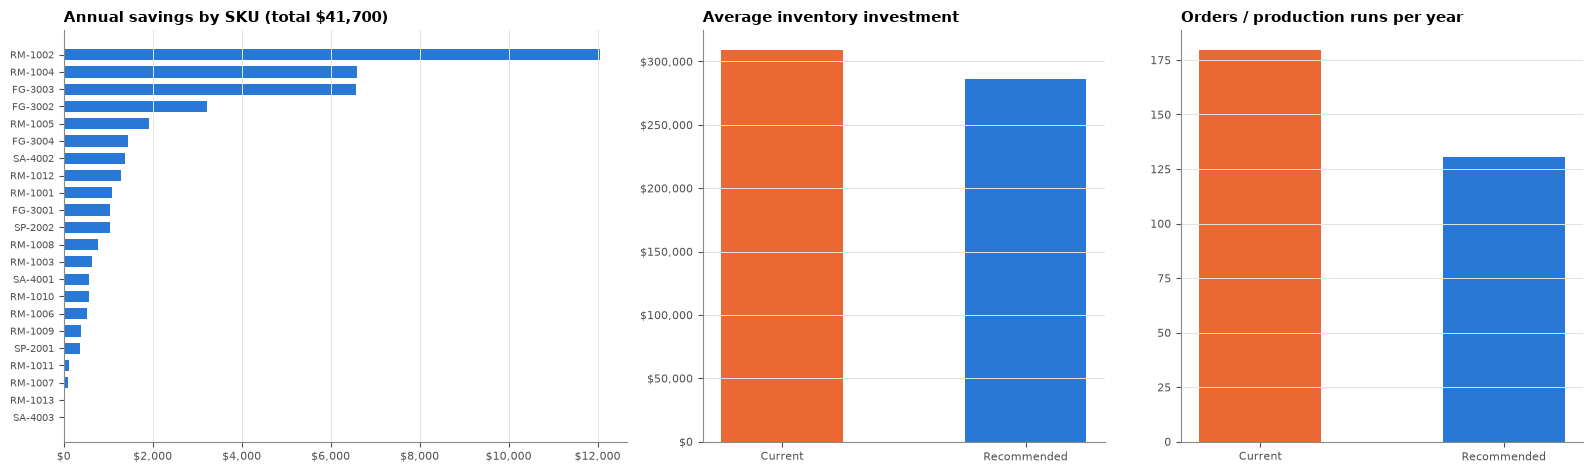

In [45]:
k = result["kpis"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw=dict(width_ratios=[1.4, 1, 1]))
s_ = res.dropna(subset=["current_q"]).sort_values("annual_savings")
axes[0].barh(s_["sku"], s_["annual_savings"], color=C_ORDER, height=0.65)
axes[0].xaxis.set_major_formatter(money); axes[0].set_title(f"Annual savings by SKU (total ${k['total_savings']:,.0f})")
axes[0].tick_params(axis="y", labelsize=7); axes[0].grid(axis="y", visible=False)
axes[1].bar(["Current", "Recommended"], [k["inv_value_current"], res.dropna(subset=["current_q"])["avg_inventory_value"].sum()],
            color=[C_CARRY, C_ORDER], width=0.5)
axes[1].yaxis.set_major_formatter(money); axes[1].set_title("Average inventory investment"); axes[1].grid(axis="x", visible=False)
axes[2].bar(["Current", "Recommended"], [k["orders_current"], res.dropna(subset=["current_q"])["orders_per_year"].sum()],
            color=[C_CARRY, C_ORDER], width=0.5)
axes[2].set_title("Orders / production runs per year"); axes[2].grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

### 14.4 One SKU in detail
The PDF report has one page like this for every item. Here is **RM-1003**: its supplier offers a price break at 1,000 units. The tool classifies it as lecture **Case 1**.

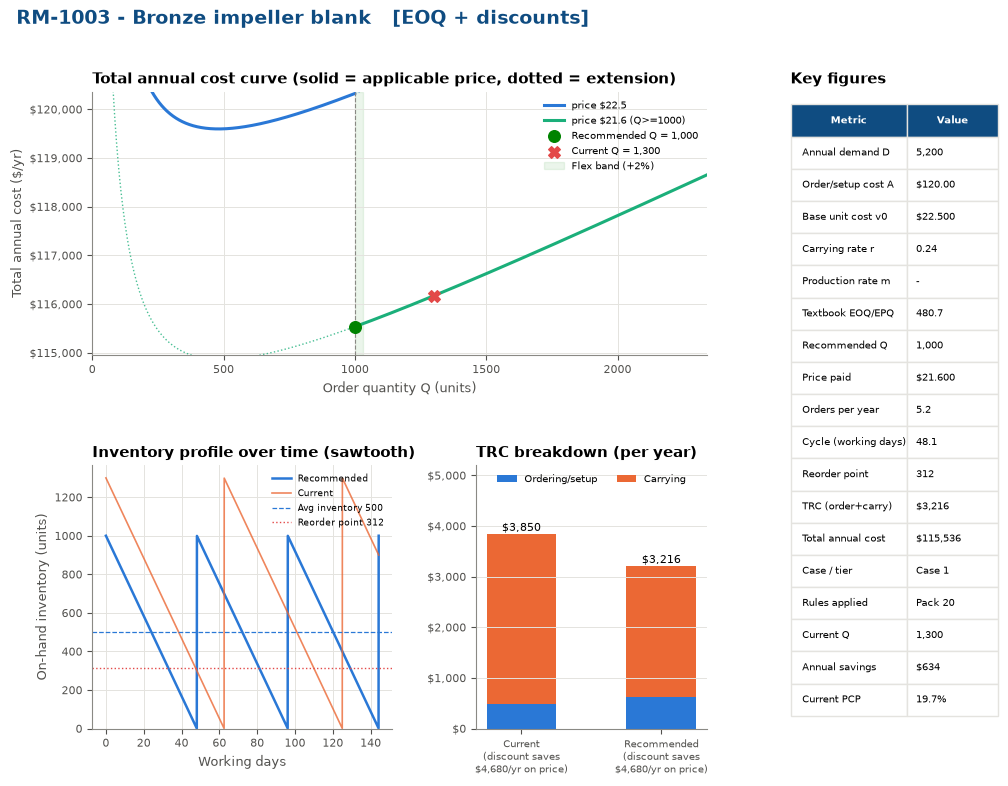

Step 1: EOQ at the discounted price v0(1-d) = 21.6000:  EOQ(d) = sqrt(2AD/(v0(1-d)r)) = 490.65
Step 2: EOQ(d) = 490.65 < Q1 = 1,000  ->  go to step 3.
Step 3: EOQ without discount = sqrt(2AD/(v0 r)) = 480.74
        TRC(EOQ) = sqrt(2AD v0 r) + D v0 = 119,596.00
        TRC(Q1)  = AD/Q1 + Q1 v0(1-d) r/2 + D v0(1-d) = 115,536.00
        TRC(EOQ) > TRC(Q1)  ->  take the discount, order exactly Q1 (CASE 1).

==> Optimal order quantity Q* = 1,000.00  (Case 1),  total annual cost = $115,536.00


In [46]:
it = {i.sku: i for i in result["items"]}["RM-1003"]
row = res.set_index("sku").loc["RM-1003"]; row["sku"] = "RM-1003"
lst.sku_figure(it, row, result["settings"]); plt.show()
# cross-check with the lecture procedure (single break)
_ = solve_all_units(it.A, it.D, it.r, it.v0, 1 - it.breaks[1][1] / it.v0, it.breaks[1][0])

### 14.5 What-if analysis: a setup-reduction (SMED) project
The plant considers a quick-changeover project that **halves the setup cost A of every produced item**. How do the lot sizes and costs change? The tool answers this by running a modified input. This is how you would build the business case in practice.

Lot-Sizing Tool v1.0.0  |  Delta Pumps & Valves Co. (fictional case)
  items analysed        : 22  (validation messages: 2)
  annual savings        : $44,516.48
  avg inventory value   : $309,125 (current) -> $236,304 (recommended, all items)
  Excel results         : c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\industrial_tool\output\whatif_setup_reduction_results.xlsx
  PDF report            : c:\Users\islam\Documents\GitHub\IME452_InventoryManagementAndControl_FALL2026\Lecture02\industrial_tool\output\whatif_setup_reduction_report.pdf


sku,recommended_q (today),annual_relevant_cost (today),recommended_q (after SMED),annual_relevant_cost (after SMED)
FG-3001,410,"21,022",290,"14,865"
FG-3002,260,"20,795",185,"14,705"
FG-3003,760,"12,736",540,"9,006"
FG-3004,"1,300","8,897",950,"6,292"
SA-4001,910,"4,507",640,"3,187"
SA-4002,660,"6,635",465,"4,692"
SA-4003,600,"4,272",480,"2,998"


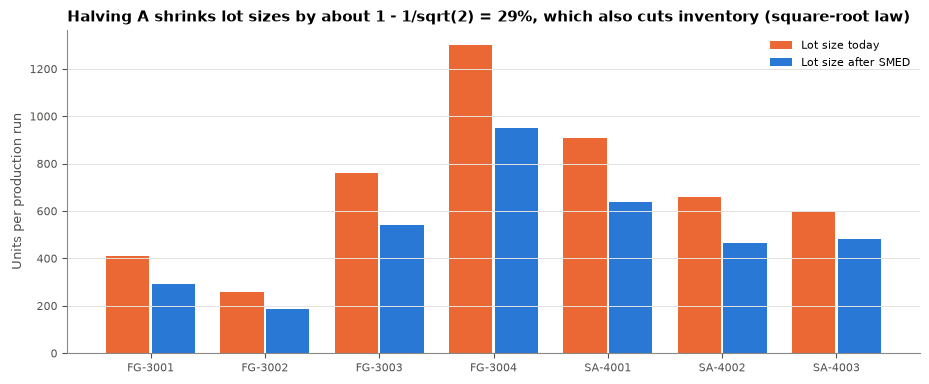

In [47]:
items_in = pd.read_excel(xin, sheet_name="Items"); breaks_in = pd.read_excel(xin, sheet_name="PriceBreaks")
settings_in = dict(pd.read_excel(xin, sheet_name="Settings")[["setting", "value"]].values)
whatif = items_in.copy()
whatif.loc[whatif.supply_type == "Produced", "order_cost"] *= 0.5
settings_in["report_title"] = "What-if: setup cost reduced by 50% (SMED)"
xin2 = os.path.join(TOOL_DIR, "input", "whatif_setup_reduction_input.xlsx")
lst.write_input_workbook(xin2, settings_in, whatif, breaks_in)
res2 = lst.run(xin2, os.path.join(TOOL_DIR, "output"), sku_pages=5)["results"]

cmp_ = res[res.supply_type == "Produced"][["sku", "recommended_q", "annual_relevant_cost"]].merge(
       res2[["sku", "recommended_q", "annual_relevant_cost"]], on="sku", suffixes=(" (today)", " (after SMED)"))
display(cmp_.style.format({c: "{:,.0f}" for c in cmp_.columns if c != "sku"}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(11, 4.2))
x = np.arange(len(cmp_))
ax.bar(x - 0.2, cmp_["recommended_q (today)"], 0.38, color=C_CARRY, label="Lot size today")
ax.bar(x + 0.2, cmp_["recommended_q (after SMED)"], 0.38, color=C_ORDER, label="Lot size after SMED")
ax.set_xticks(x, cmp_["sku"]); ax.set_ylabel("Units per production run"); ax.legend(); ax.grid(axis="x", visible=False)
ax.set_title("Halving A shrinks lot sizes by about 1 - 1/sqrt(2) = 29%, which also cuts inventory (square-root law)")
plt.show()

### 14.6 Outputs produced

In [48]:
outdir = os.path.join(TOOL_DIR, "output")
for f in sorted(os.listdir(outdir)):
    print(f"  industrial_tool/output/{f:45s} {os.path.getsize(os.path.join(outdir, f))/1024:8.1f} kB")
xres = pd.ExcelFile(os.path.join(outdir, "example_company_results.xlsx"))
print("\nSheets in the Excel results:", xres.sheet_names)
display(pd.read_excel(xres, sheet_name="Summary"))

  industrial_tool/output/example_company_report.pdf                       271.4 kB
  industrial_tool/output/example_company_results.xlsx                      19.2 kB
  industrial_tool/output/whatif_setup_reduction_report.pdf                124.9 kB
  industrial_tool/output/whatif_setup_reduction_results.xlsx               19.2 kB

Sheets in the Excel results: ['README', 'Summary', 'Recommendations', 'Column_Guide', 'Validation_Log', 'Input_Items', 'Input_PriceBreaks']


,KPI,Value,Scope
0,Items analysed,2.200000e+01,NaN
1,Items with a current policy,2.200000e+01,NaN
2,Items where a quantity discount is taken,9.000000e+00,NaN
3,Total annual cost - recommended ($),4.830442e+06,all items
4,Ordering + carrying cost (TRC) - recommended ($),1.139118e+05,all items
5,Total annual cost - current ($),4.872142e+06,items with current policy
6,Annual savings ($),4.170005e+04,items with current policy
7,Average inventory value - recommended ($),2.861723e+05,all items
8,Average inventory value - current ($),3.091250e+05,items with current policy
9,Orders per year - recommended,1.302915e+02,all items


### 14.7 Student exercises with the tool
1. **Data audit.** Open `example_company_input.xlsx` and explain the two entries in the validation log. Correct them and run the tool again.
2. **Your own company.** Create a template (`--template`) and enter 10 items from a company you know (or from your internship). Where would you find A, r and D in that company's ERP system?
3. **Negotiation.** For `RM-1003`, what is the smallest discount at the 1,000-unit break that still makes Case 1 optimal? Check your answer with the discount decision map from Section 11.
4. **Pallet rounding.** Change the `pack_size` of `RM-1004` to 500. Is the new recommendation inside the flexibility band? What does the PCP say?
5. **Interest rates.** Raise `default_carrying_rate` from 0.24 to 0.36. By what percentage do the order quantities change? Compare with $\sqrt{0.24/0.36}$.
6. **Critical thinking.** Which of the nine EOQ assumptions are *least* realistic for the finished goods FG-3001…FG-3004? What would you tell your manager?

<a id="s15"></a>
## 15. Formula sheet

| Concept | Formula |
|---|---|
| Replenishment cost / unit time | $C_r=\dfrac{A+Qv}{Q/D}=\dfrac{AD}{Q}+vD$ |
| Carrying cost / unit time | $C_c=\bar I vr=\dfrac{Qvr}{2}$ |
| Total relevant cost | $TRC(Q)=\dfrac{Qvr}{2}+\dfrac{AD}{Q}$ |
| EOQ (Wilson) | $EOQ=\sqrt{\dfrac{2AD}{vr}}$ |
| Cost at EOQ | $TRC(EOQ)=\sqrt{2ADvr}$ (ordering = carrying = $\sqrt{ADvr/2}$) |
| Months of supply | $T_{EOQ}=\sqrt{\dfrac{288A}{Dvr}}$ |
| Turnover ratio | $TR=\dfrac{D}{\bar I}=\sqrt{\dfrac{2vrD}{A}}$ |
| Percentage cost penalty | $Q'=(1+\alpha)EOQ,\quad PCP=50\dfrac{\alpha^2}{1+\alpha}$ |
| EPQ | $TRC=\dfrac{AD}{Q}+\dfrac{Q(1-D/m)vr}{2},\quad EPQ=\sqrt{\dfrac{2AD}{vr(1-D/m)}}=\dfrac{EOQ}{\sqrt{1-D/m}}$ |
| Max inventory (EPQ) | $Q(1-D/m)$ |
| All-units discount | $TRC(Q)=A\dfrac{D}{Q}+\dfrac{Q}{2}vr+Dv$, $v=v_0$ or $v_0(1-d)$ |
| Discount procedure | 1) $EOQ(d)$; if $\ge Q_1$ → Case 3. 2) else compare $TRC(EOQ_0)=\sqrt{2ADv_0r}+Dv_0$ with $TRC(Q_1)$ → Case 2 or Case 1 |

**Reports generated by this notebook** (folder `reports/`):

In [49]:
for f in sorted(os.listdir(REPORT_DIR)):
    if f.endswith(".pdf"):
        print(f"  reports/{f:50s} {os.path.getsize(os.path.join(REPORT_DIR, f))/1024:8.1f} kB")

  reports/Example1_EOQ_Report.pdf                                71.7 kB
  reports/Example2_EPQ_Report.pdf                                53.4 kB
  reports/Example3_Quantity_Discount_Cases.pdf                  580.1 kB
  reports/Full_Lecture_Report.pdf                               601.2 kB
  reports/Sensitivity_Analysis_Report.pdf                        69.2 kB


---
*End of notebook. Questions: islam.ali@ejust.edu.eg*